In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("../outputs/gender_output_2025-10-08 10:26:11.109161_VicregLoss_gru_catboost/out_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
len(df_all)

7200

In [4]:
print(df_all)

      batch_size  learning_rate  split_count  cnt_min  cnt_max  embedding_dim  \
0             16          0.001            3       10      100             32   
1             16          0.001            3       10      100             32   
2             16          0.001            3       10      100             32   
3             16          0.001            3       10      100             32   
4             16          0.001            3       10      100             32   
...          ...            ...          ...      ...      ...            ...   
7195         128          0.001            3       10      100             32   
7196         128          0.001            3       10      100             32   
7197         128          0.001            3       10      100             32   
7198         128          0.001            3       10      100             32   
7199         128          0.001            3       10      100             32   

      category_embedding_di

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = scaled[:, 0] - scaled[:, 1]
df_all['ripser_weighted'] = weighted_sum

In [ ]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['ripser_weighted', 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

In [7]:
df_all = df_all.set_index('checkpoint')

In [8]:
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))

        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })

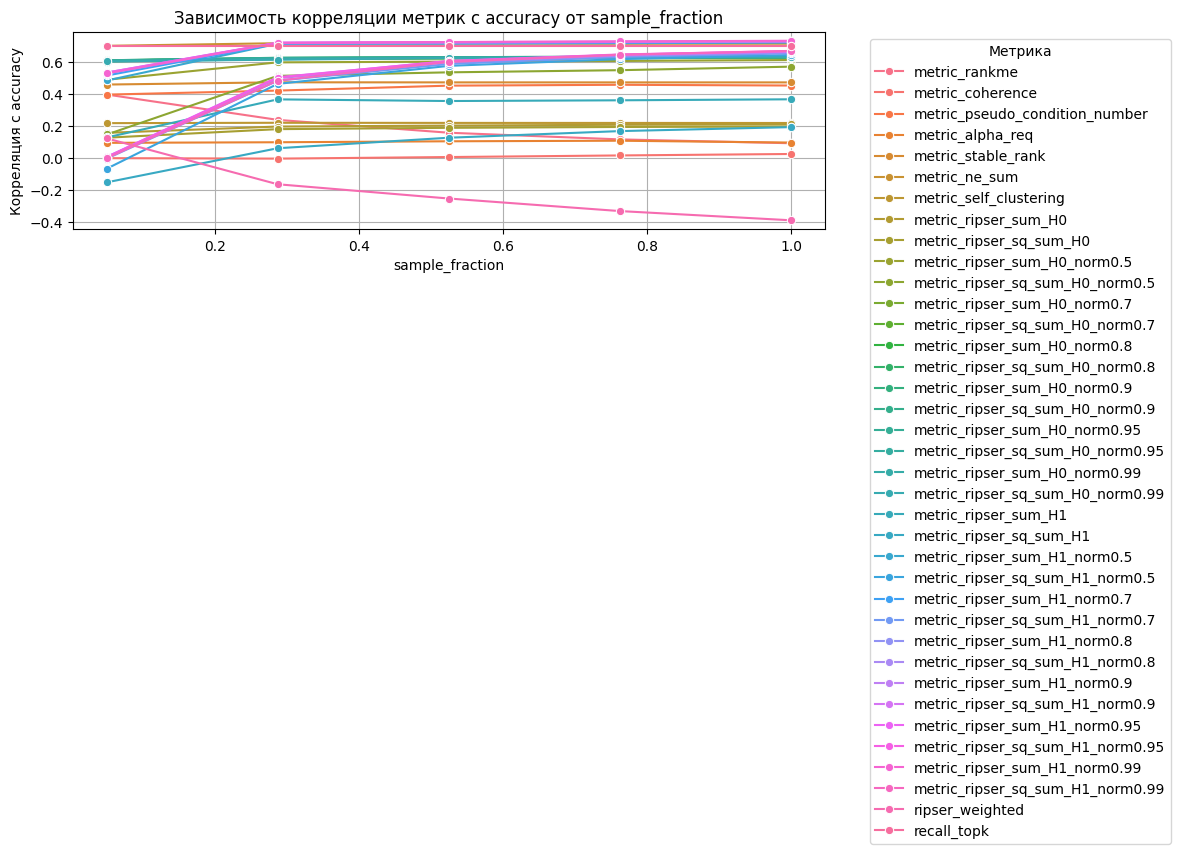

In [9]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [10]:
print(corr_df)

     sample_fraction                            metric  correlation
0               0.05                     metric_rankme     0.398171
1               0.05                  metric_coherence     0.000255
2               0.05    metric_pseudo_condition_number     0.397895
3               0.05                  metric_alpha_req     0.095996
4               0.05                metric_stable_rank     0.460851
..               ...                               ...          ...
180             1.00  metric_ripser_sq_sum_H1_norm0.95     0.670344
181             1.00     metric_ripser_sum_H1_norm0.99     0.734798
182             1.00  metric_ripser_sq_sum_H1_norm0.99     0.671468
183             1.00                   ripser_weighted    -0.388572
184             1.00                       recall_topk     0.699428

[185 rows x 3 columns]


In [11]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.714643
recall_topk                         0.699428
metric_ripser_sum_H1_norm0.95       0.689515
metric_ripser_sum_H1_norm0.99       0.689070
metric_ripser_sum_H1_norm0.9        0.688471
metric_ripser_sum_H1_norm0.8        0.685407
metric_ripser_sum_H1_norm0.7        0.680666
metric_ripser_sum_H1_norm0.5        0.672718
metric_ripser_sum_H0_norm0.9        0.628546
metric_ripser_sum_H0_norm0.95       0.628135
metric_ripser_sum_H0_norm0.8        0.626957
metric_ripser_sq_sum_H0_norm0.9     0.626186
metric_ripser_sq_sum_H0_norm0.95    0.625763
metric_ripser_sq_sum_H0_norm0.8     0.624640
metric_ripser_sum_H0_norm0.99       0.624288
metric_ripser_sum_H0_norm0.7        0.623419
metric_ripser_sq_sum_H0_norm0.99    0.621815
metric_ripser_sq_sum_H0_norm0.7     0.621071
metric_ripser_sum_H0_norm0.5        0.583536
metric_ripser_sq_sum_H1_norm0.95    0.487941
metric_ripser_sq_sum_H1_norm0.9     0.487643
metric_ripser_sq_sum_H1_norm0.8     0.482362
met

In [12]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H1_norm0.99       0.734798
metric_ripser_sum_H1_norm0.95       0.732593
metric_ripser_sum_H1_norm0.9        0.731094
metric_ripser_sum_H1_norm0.8        0.728832
metric_ripser_sum_H1_norm0.7        0.726213
metric_ripser_sum_H1_norm0.5        0.724010
metric_ne_sum                       0.716381
recall_topk                         0.699428
metric_ripser_sq_sum_H1_norm0.99    0.671468
metric_ripser_sq_sum_H1_norm0.95    0.670344
metric_ripser_sq_sum_H1_norm0.9     0.668142
metric_ripser_sq_sum_H1_norm0.8     0.663087
metric_ripser_sq_sum_H1_norm0.7     0.656049
metric_ripser_sq_sum_H1_norm0.5     0.645649
metric_ripser_sum_H0_norm0.95       0.636012
metric_ripser_sum_H0_norm0.9        0.635910
metric_ripser_sum_H0_norm0.99       0.635363
metric_ripser_sum_H0_norm0.8        0.634390
metric_ripser_sq_sum_H0_norm0.95    0.631974
metric_ripser_sq_sum_H0_norm0.9     0.631803
metric_ripser_sq_sum_H0_norm0.99    0.631530
metric_ripser_sum_H0_norm0.7        0.631281
met

In [13]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.711379
recall_topk                         0.699428
metric_ripser_sum_H1_norm0.95       0.629549
metric_ripser_sum_H1_norm0.9        0.629078
metric_ripser_sum_H1_norm0.99       0.626326
metric_ripser_sum_H1_norm0.8        0.624977
metric_ripser_sum_H0_norm0.9        0.619884
metric_ripser_sq_sum_H0_norm0.9     0.619622
metric_ripser_sum_H0_norm0.95       0.618689
metric_ripser_sq_sum_H0_norm0.8     0.618667
metric_ripser_sum_H0_norm0.8        0.618641
metric_ripser_sq_sum_H0_norm0.95    0.618271
metric_ripser_sum_H1_norm0.7        0.617262
metric_ripser_sq_sum_H0_norm0.7     0.614841
metric_ripser_sum_H0_norm0.7        0.614692
metric_ripser_sum_H0_norm0.99       0.612035
metric_ripser_sq_sum_H0_norm0.99    0.611153
metric_ripser_sum_H1_norm0.5        0.601382
metric_ripser_sum_H0_norm0.5        0.545384
metric_stable_rank                  0.467888
metric_pseudo_condition_number      0.410490
metric_ripser_sq_sum_H0_norm0.5     0.331751
met

# Overall Spearmann Corr

In [14]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })
            


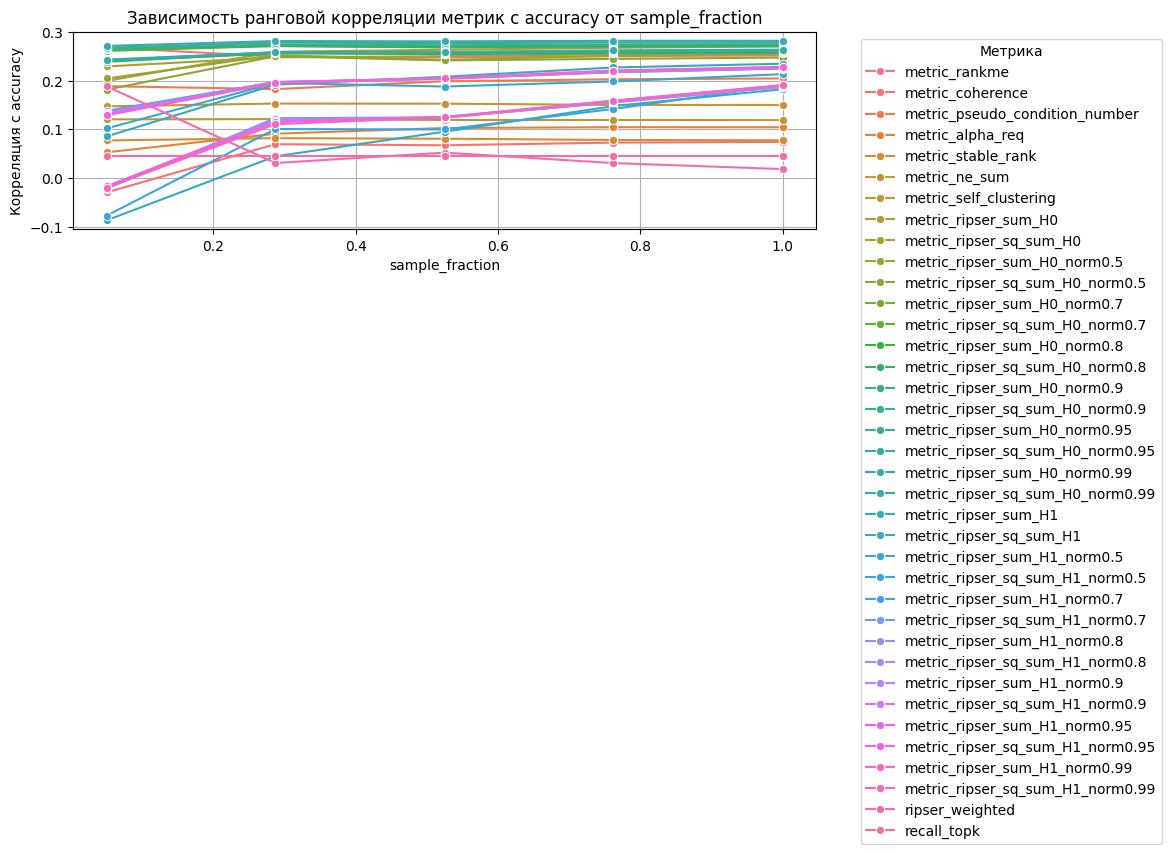

In [15]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [16]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.99': 0.2816334926016578,
 'metric_ripser_sq_sum_H0_norm0.95': 0.2778454630163299,
 'metric_ripser_sq_sum_H0_norm0.9': 0.27417375087313745,
 'metric_ripser_sq_sum_H0_norm0.8': 0.27109631417066865,
 'metric_ripser_sq_sum_H0_norm0.7': 0.270623175362816,
 'metric_ripser_sq_sum_H0': 0.2701266001638275,
 'metric_ripser_sum_H0_norm0.99': 0.26351950467060054,
 'metric_ripser_sum_H0_norm0.95': 0.2614547464096329,
 'metric_ripser_sum_H0_norm0.9': 0.25908492460266347,
 'metric_ripser_sum_H0_norm0.7': 0.25822643746542373,
 'metric_ripser_sum_H0_norm0.8': 0.25756002854652477,
 'metric_ripser_sum_H0': 0.2560096873087376,
 'metric_ripser_sum_H0_norm0.5': 0.25507959174102113,
 'metric_rankme': 0.25161736624658154,
 'metric_ripser_sq_sum_H0_norm0.5': 0.24720436622794717,
 'metric_ripser_sum_H1': 0.2346786664474104,
 'metric_ripser_sum_H1_norm0.99': 0.2281447952508422,
 'metric_ripser_sum_H1_norm0.95': 0.22737725673452397,
 'metric_ripser_sum_H1_norm0.9': 0.22603487282310

In [17]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.99': 0.2792487424562197,
 'metric_ripser_sq_sum_H0_norm0.95': 0.2756481517769198,
 'metric_ripser_sq_sum_H0_norm0.9': 0.27185473438755575,
 'metric_ripser_sq_sum_H0_norm0.8': 0.26940939705863154,
 'metric_ripser_sq_sum_H0_norm0.7': 0.26815999767499393,
 'metric_ripser_sum_H0_norm0.99': 0.2570792987515069,
 'metric_ripser_sum_H0_norm0.95': 0.2559714829361997,
 'metric_ripser_sum_H0_norm0.7': 0.25394642182047306,
 'metric_ripser_sum_H0_norm0.9': 0.25372887394095983,
 'metric_rankme': 0.2532319886476969,
 'metric_ripser_sum_H0_norm0.8': 0.2529461985276534,
 'metric_ripser_sq_sum_H0': 0.2518988953364379,
 'metric_ripser_sum_H0': 0.24741024968295297,
 'metric_ripser_sum_H0_norm0.5': 0.24094399092558244,
 'metric_ripser_sq_sum_H0_norm0.5': 0.2329650981076176,
 'metric_ripser_sum_H1_norm0.7': 0.19639923684164987,
 'metric_ripser_sum_H1_norm0.95': 0.19602801133479608,
 'metric_ripser_sum_H1_norm0.8': 0.19572710275689856,
 'metric_ripser_sum_H1_norm0.9': 0.195592

In [18]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.99': 0.2761511292618742,
 'metric_ripser_sq_sum_H0_norm0.95': 0.27273553204129564,
 'metric_ripser_sq_sum_H0_norm0.9': 0.26935273176008234,
 'metric_ripser_sq_sum_H0_norm0.8': 0.26849992947425305,
 'metric_ripser_sq_sum_H0_norm0.7': 0.26592341957244386,
 'metric_rankme': 0.25855016772017314,
 'metric_ripser_sum_H0_norm0.99': 0.2504849015419125,
 'metric_ripser_sum_H0_norm0.95': 0.25001505495115434,
 'metric_ripser_sum_H0_norm0.7': 0.24886602374977415,
 'metric_ripser_sum_H0_norm0.8': 0.2481202364624562,
 'metric_ripser_sum_H0_norm0.9': 0.24779237395199388,
 'metric_ripser_sum_H0': 0.23841557499939314,
 'metric_ripser_sq_sum_H0': 0.22935363110099388,
 'metric_ripser_sum_H0_norm0.5': 0.22816321874977386,
 'metric_ripser_sq_sum_H0_norm0.5': 0.21578482174056024,
 'metric_pseudo_condition_number': 0.1855810345220366,
 'metric_ripser_sum_H1_norm0.7': 0.1676560475324397,
 'metric_ripser_sum_H1_norm0.8': 0.16639345764630376,
 'metric_ripser_sum_H1_norm0.9': 0.16

# Correlation for best checkpoint choice

In [19]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
            


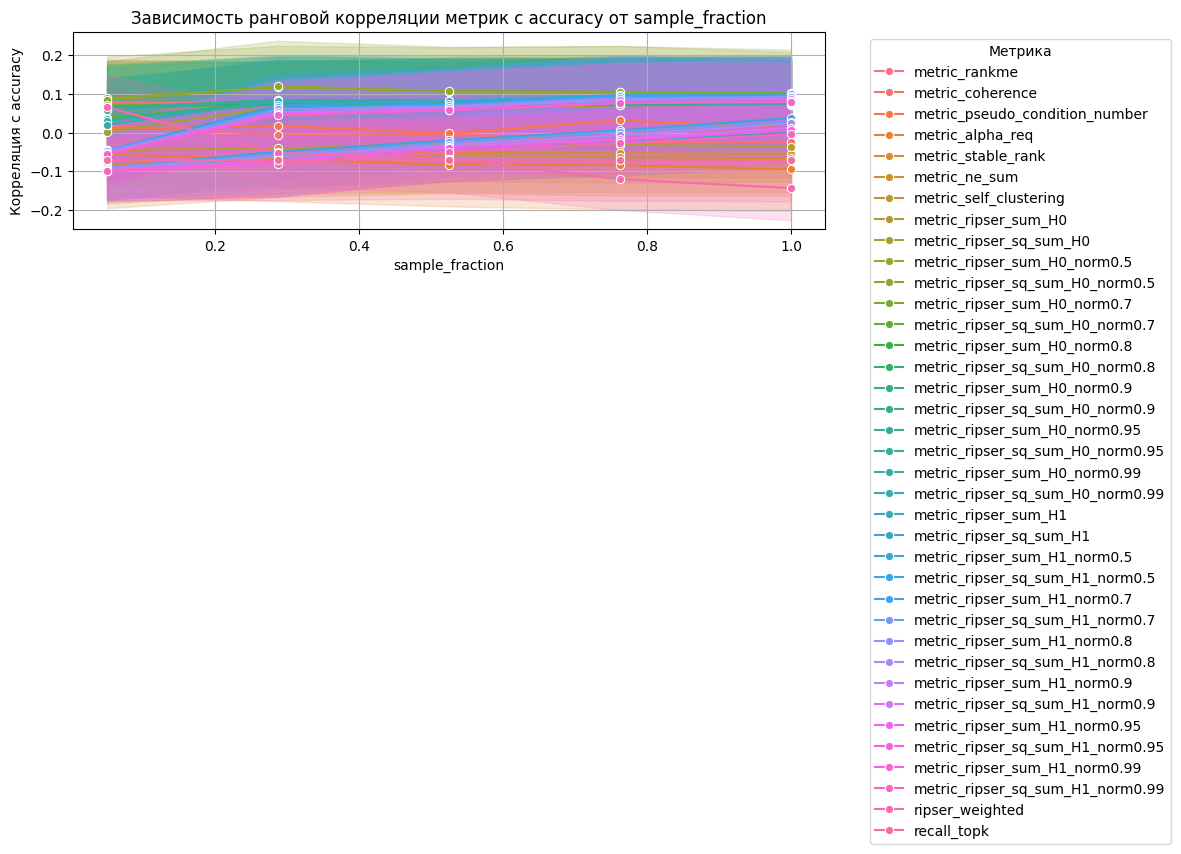

In [20]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [21]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.5': 0.10238369494946538,
 'metric_ripser_sq_sum_H0_norm0.5': 0.10221858806444296,
 'metric_ripser_sum_H1_norm0.5': 0.10012914640832661,
 'metric_ripser_sum_H1_norm0.7': 0.09408932325399218,
 'metric_ripser_sum_H1_norm0.8': 0.09209236865906079,
 'metric_ripser_sum_H1_norm0.9': 0.0868739316386664,
 'metric_ripser_sum_H1': 0.08496531335077799,
 'metric_ripser_sum_H1_norm0.95': 0.08108752242369263,
 'metric_ripser_sum_H1_norm0.99': 0.0788041522792916,
 'metric_ripser_sum_H0_norm0.99': 0.07865144746093612,
 'metric_ripser_sum_H0': 0.07835584837132692,
 'metric_ripser_sq_sum_H0_norm0.7': 0.0775615328740096,
 'metric_ripser_sum_H0_norm0.8': 0.0769926000013453,
 'metric_ripser_sq_sum_H0_norm0.8': 0.07646434198428816,
 'metric_ripser_sum_H0_norm0.7': 0.0759942999769937,
 'metric_ripser_sum_H0_norm0.95': 0.07540874498635296,
 'metric_ripser_sq_sum_H0_norm0.99': 0.07522128083386995,
 'metric_ripser_sq_sum_H0_norm0.95': 0.0749479180536537,
 'metric_ripser_sum_H0_norm0.

In [22]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.5': 0.10363010874443884,
 'metric_ripser_sq_sum_H0_norm0.5': 0.10343925741901625,
 'metric_ripser_sum_H0_norm0.95': 0.0769191739195071,
 'metric_ripser_sum_H0_norm0.99': 0.07614164314415597,
 'metric_ripser_sum_H0_norm0.9': 0.07601491875674372,
 'metric_rankme': 0.07527233321937052,
 'metric_ripser_sum_H0_norm0.7': 0.07449989257362644,
 'metric_ripser_sum_H0_norm0.8': 0.07376403955029961,
 'metric_ripser_sum_H0': 0.07368792007753916,
 'metric_ripser_sq_sum_H0_norm0.7': 0.06905745404876179,
 'metric_ripser_sq_sum_H0_norm0.95': 0.06675131900295592,
 'metric_ripser_sq_sum_H0_norm0.9': 0.06611842971414239,
 'metric_ripser_sq_sum_H0_norm0.8': 0.0657769180877336,
 'metric_ripser_sq_sum_H0_norm0.99': 0.06498978217632907,
 'metric_ripser_sum_H1_norm0.5': 0.060440563506418854,
 'metric_ripser_sum_H1_norm0.7': 0.05593913372367597,
 'metric_ripser_sq_sum_H0': 0.054150331404566744,
 'metric_ripser_sum_H1_norm0.8': 0.05209187140059602,
 'metric_ripser_sum_H1': 0.0480982

In [23]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.5': 0.10257238699803302,
 'metric_ripser_sq_sum_H0_norm0.5': 0.10160301958867297,
 'metric_rankme': 0.07633210343909323,
 'metric_ripser_sum_H0_norm0.9': 0.07390805955350718,
 'metric_ripser_sum_H0_norm0.95': 0.07323830234834805,
 'metric_ripser_sum_H0_norm0.7': 0.07202026590295725,
 'metric_ripser_sum_H0_norm0.99': 0.0698740370695393,
 'metric_ripser_sum_H0_norm0.8': 0.06914320744409606,
 'metric_ripser_sum_H0': 0.06650942903207374,
 'metric_ripser_sq_sum_H0_norm0.7': 0.057866385815706745,
 'metric_ripser_sq_sum_H0_norm0.9': 0.056995147571847586,
 'metric_ripser_sq_sum_H0_norm0.95': 0.054326159984569036,
 'metric_ripser_sq_sum_H0_norm0.8': 0.05384360541458248,
 'metric_ripser_sq_sum_H0_norm0.99': 0.05027175232394273,
 'metric_ripser_sq_sum_H0': 0.03399601237223489,
 'metric_pseudo_condition_number': 0.013371575808151768,
 'metric_ripser_sum_H1_norm0.5': 0.011820997413958118,
 'metric_ripser_sum_H1_norm0.7': 0.009054079782061063,
 'ripser_weighted': 0.00665

# Linear correlation of epoch choice

In [24]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
     

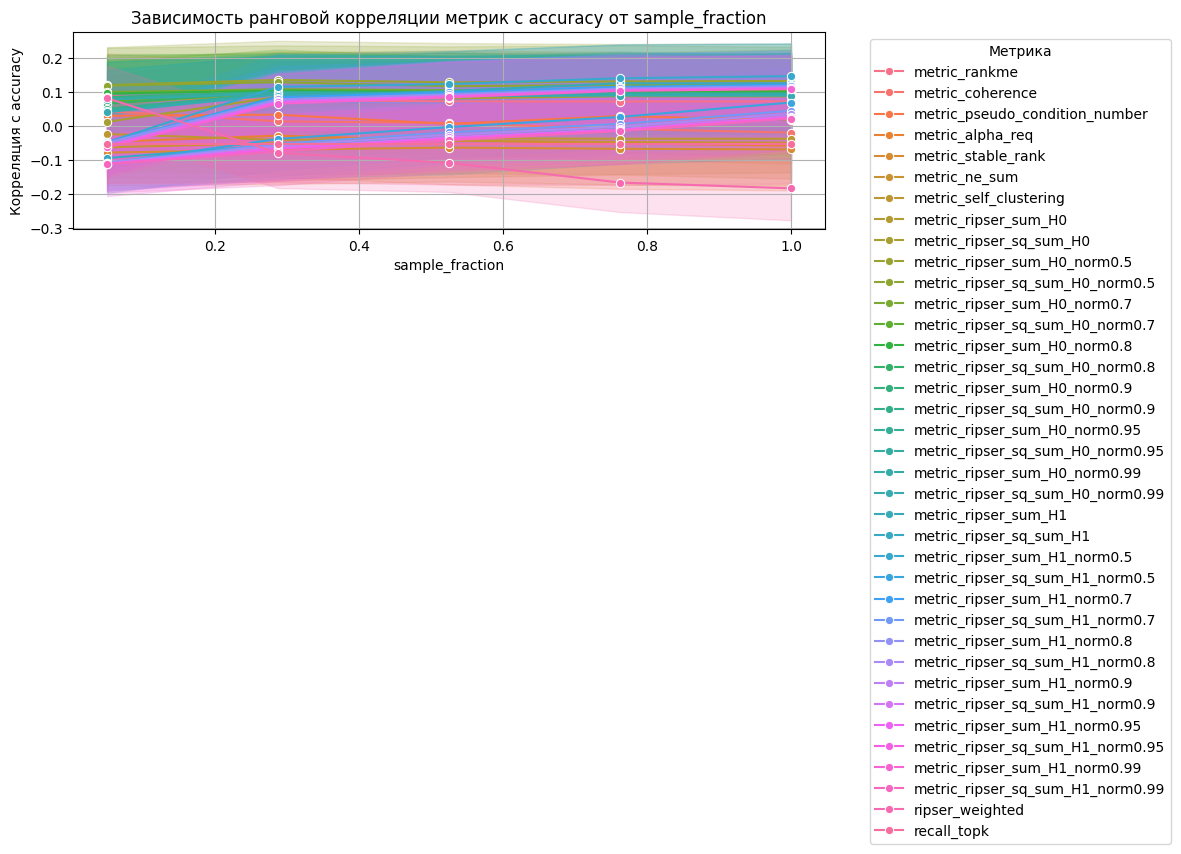

In [25]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [26]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H1_norm0.5        0.145369
metric_ripser_sum_H0_norm0.5        0.131234
metric_ripser_sum_H1                0.124141
metric_ripser_sum_H1_norm0.7        0.120449
metric_ripser_sq_sum_H0_norm0.5     0.119881
metric_ripser_sum_H1_norm0.8        0.115883
metric_ripser_sum_H1_norm0.9        0.111726
metric_ripser_sum_H1_norm0.95       0.109936
metric_ripser_sum_H1_norm0.99       0.107497
metric_ripser_sum_H0_norm0.7        0.103597
metric_ripser_sq_sum_H0_norm0.7     0.101302
metric_ripser_sum_H0_norm0.8        0.097864
metric_ripser_sum_H0                0.095214
metric_ripser_sq_sum_H0_norm0.8     0.094541
metric_ripser_sum_H0_norm0.9        0.094473
metric_ripser_sum_H0_norm0.95       0.093628
metric_ripser_sum_H0_norm0.99       0.091760
metric_ripser_sq_sum_H0_norm0.9     0.090996
metric_ripser_sq_sum_H0_norm0.95    0.090004
metric_ripser_sq_sum_H0_norm0.99    0.087817
metric_ripser_sq_sum_H0             0.085674
metric_rankme                       0.071306
met

In [27]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H0_norm0.5        0.126610
metric_ripser_sq_sum_H0_norm0.5     0.122505
metric_ripser_sum_H0_norm0.7        0.102723
metric_ripser_sum_H0_norm0.8        0.098339
metric_ripser_sum_H0_norm0.9        0.091155
metric_ripser_sum_H0_norm0.95       0.088765
metric_ripser_sq_sum_H0_norm0.7     0.087509
metric_ripser_sum_H0_norm0.99       0.085748
metric_ripser_sq_sum_H0_norm0.8     0.081954
metric_rankme                       0.080643
metric_ripser_sum_H0                0.079117
metric_ripser_sq_sum_H0_norm0.9     0.072744
metric_ripser_sq_sum_H0_norm0.95    0.069655
metric_ripser_sq_sum_H0_norm0.99    0.065363
metric_ripser_sq_sum_H0             0.047501
metric_ripser_sum_H1_norm0.5        0.032611
metric_pseudo_condition_number      0.030318
metric_ripser_sum_H1_norm0.7        0.016948
metric_ripser_sum_H1                0.014169
metric_ripser_sum_H1_norm0.8        0.013347
metric_coherence                    0.013270
metric_ripser_sum_H1_norm0.9        0.007147
met

# Score of best epoch

In [28]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[
                    np.argmax(sign * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

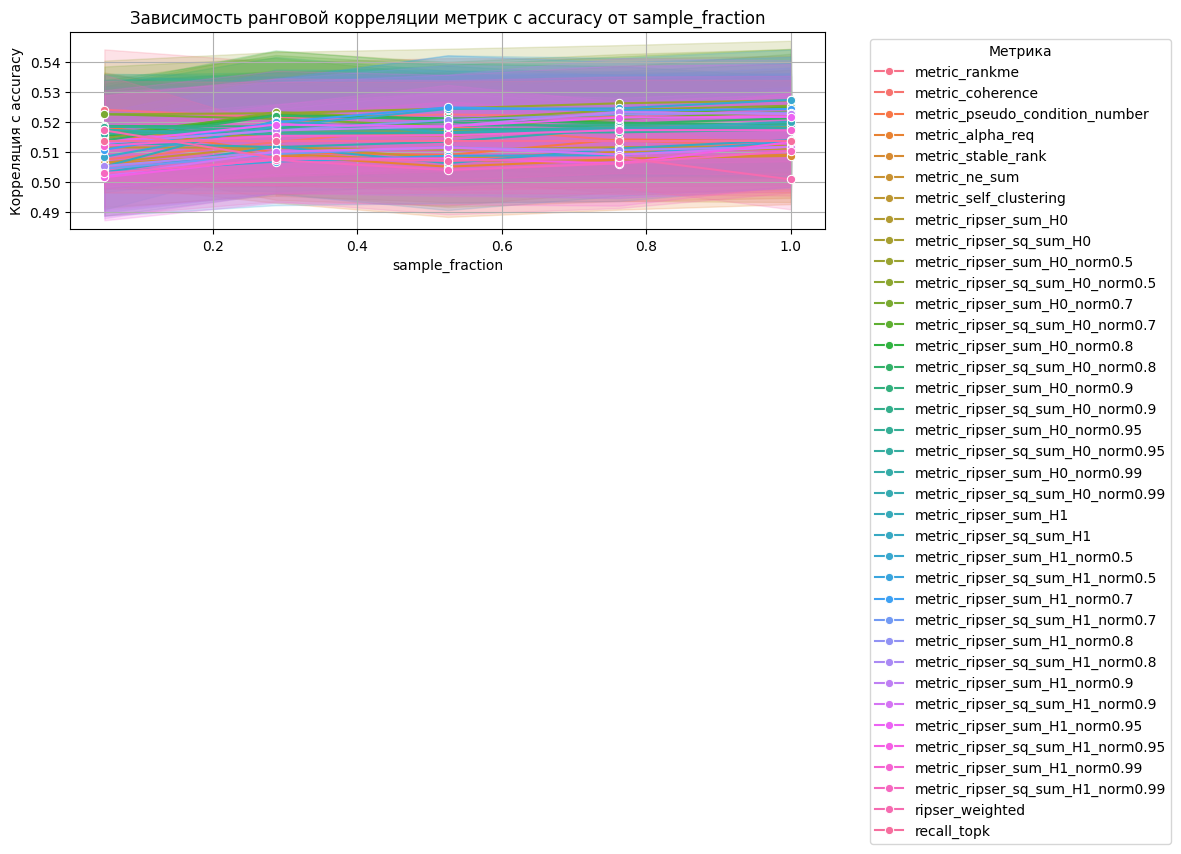

In [29]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [30]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.5': 0.5246094736842105,
 'metric_rankme': 0.5222505263157895,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5215131578947368,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5212642105263158,
 'metric_ripser_sum_H0_norm0.7': 0.5212626315789474,
 'metric_ripser_sum_H1_norm0.7': 0.5206594736842105,
 'metric_ripser_sum_H1_norm0.5': 0.5205721052631579,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5194168421052632,
 'metric_ripser_sum_H0_norm0.8': 0.5194121052631578,
 'metric_ripser_sum_H1_norm0.8': 0.5192405263157894,
 'metric_ripser_sum_H1_norm0.9': 0.5188773684210526,
 'metric_ripser_sum_H1_norm0.95': 0.5187431578947368,
 'metric_ripser_sum_H0_norm0.9': 0.518528947368421,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5182252631578947,
 'metric_ripser_sum_H0_norm0.95': 0.517751052631579,
 'metric_ripser_sum_H0_norm0.99': 0.5171426315789474,
 'metric_ripser_sum_H0': 0.5169936842105264,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5165573684210526,
 'metric_ripser_sq_sum_H0': 0.5160478947368421,
 'me

In [31]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H1_norm0.5': 0.5273,
 'metric_ripser_sum_H0_norm0.5': 0.527128947368421,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5253526315789474,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5248473684210526,
 'metric_ripser_sum_H1_norm0.7': 0.5242605263157895,
 'metric_ripser_sum_H0_norm0.7': 0.5234,
 'metric_ripser_sum_H1_norm0.8': 0.5230552631578947,
 'metric_ripser_sum_H1_norm0.9': 0.522578947368421,
 'metric_rankme': 0.5217,
 'metric_ripser_sum_H1_norm0.95': 0.5216447368421052,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5211684210526316,
 'metric_ripser_sum_H1': 0.5200342105263157,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5194131578947369,
 'metric_ripser_sum_H0_norm0.8': 0.5189789473684211,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5188342105263157,
 'metric_ripser_sum_H0': 0.5183315789473685,
 'metric_ripser_sum_H0_norm0.99': 0.5178736842105264,
 'metric_ripser_sum_H0_norm0.9': 0.5178131578947368,
 'metric_ripser_sum_H0_norm0.95': 0.5178131578947368,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5174

In [32]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_rankme': 0.5227105263157895,
 'metric_ripser_sum_H0_norm0.5': 0.522671052631579,
 'metric_ripser_sum_H0_norm0.7': 0.5217539473684211,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5191,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5188486842105263,
 'metric_ripser_sum_H0_norm0.8': 0.5186315789473683,
 'metric_ripser_sum_H0_norm0.9': 0.5185315789473685,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5179184210526316,
 'metric_ripser_sum_H0_norm0.95': 0.5178092105263158,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5170447368421053,
 'metric_ripser_sum_H0_norm0.99': 0.5165355263157895,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5162855263157894,
 'metric_ripser_sum_H0': 0.5161842105263158,
 'metric_ripser_sum_H1_norm0.95': 0.5160947368421053,
 'metric_ripser_sum_H1_norm0.7': 0.5152552631578947,
 'metric_ripser_sum_H1_norm0.9': 0.5150263157894738,
 'metric_ripser_sum_H1_norm0.8': 0.5150105263157895,
 'metric_ripser_sq_sum_H0': 0.514625,
 'metric_pseudo_condition_number': 0.5140855263157895,
 'metric_ripser_sum_H1_

In [33]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [34]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme nan
metric_rankme nan
metric_coherence nan
metric_coherence nan
metric_pseudo_condition_number nan
metric_pseudo_condition_number nan
metric_alpha_req nan
metric_alpha_req nan
metric_stable_rank nan
metric_stable_rank nan
metric_ne_sum nan
metric_ne_sum nan
metric_self_clustering nan
metric_self_clustering nan
metric_ripser_sum_H0 nan
metric_ripser_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_su

# Corr of best hyperparam by metric

In [ ]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric].corr(
                        check_data['roc_auc'], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": sign * corr
                    })

batch_size


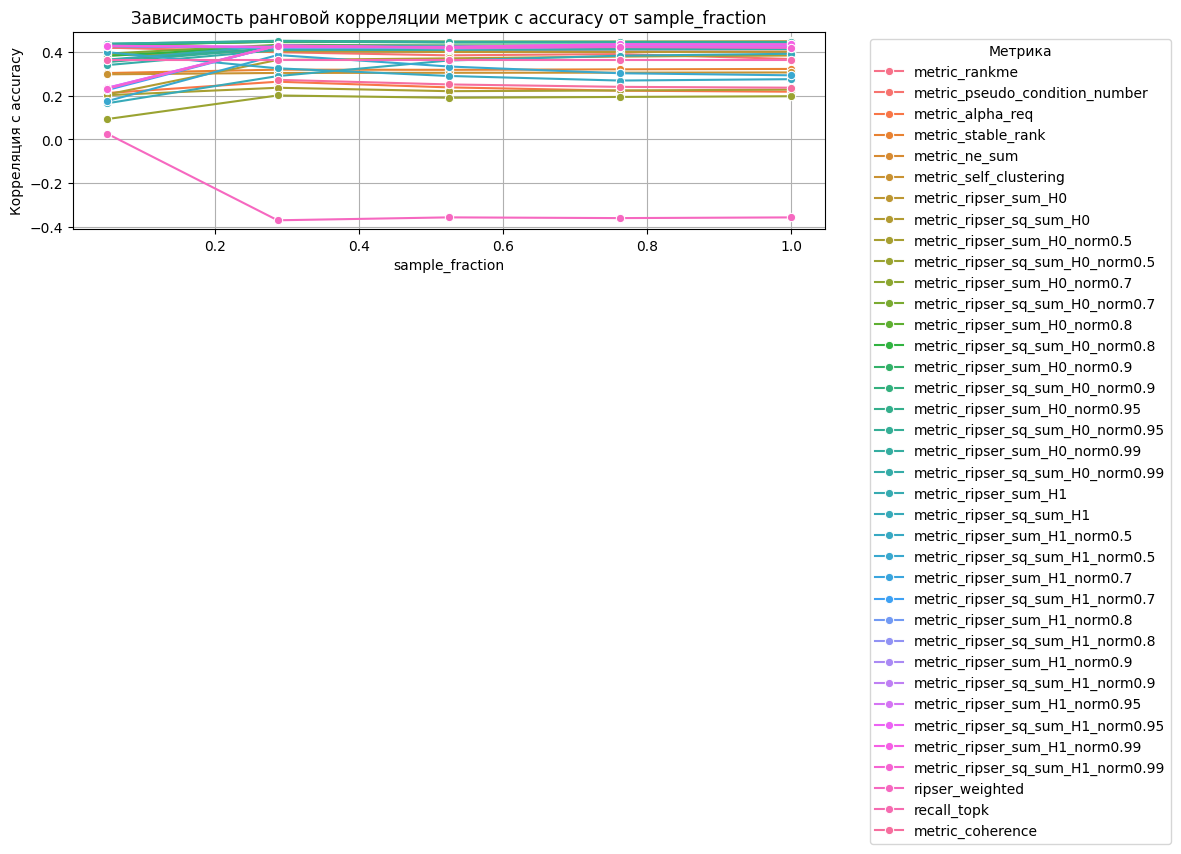

learning_rate


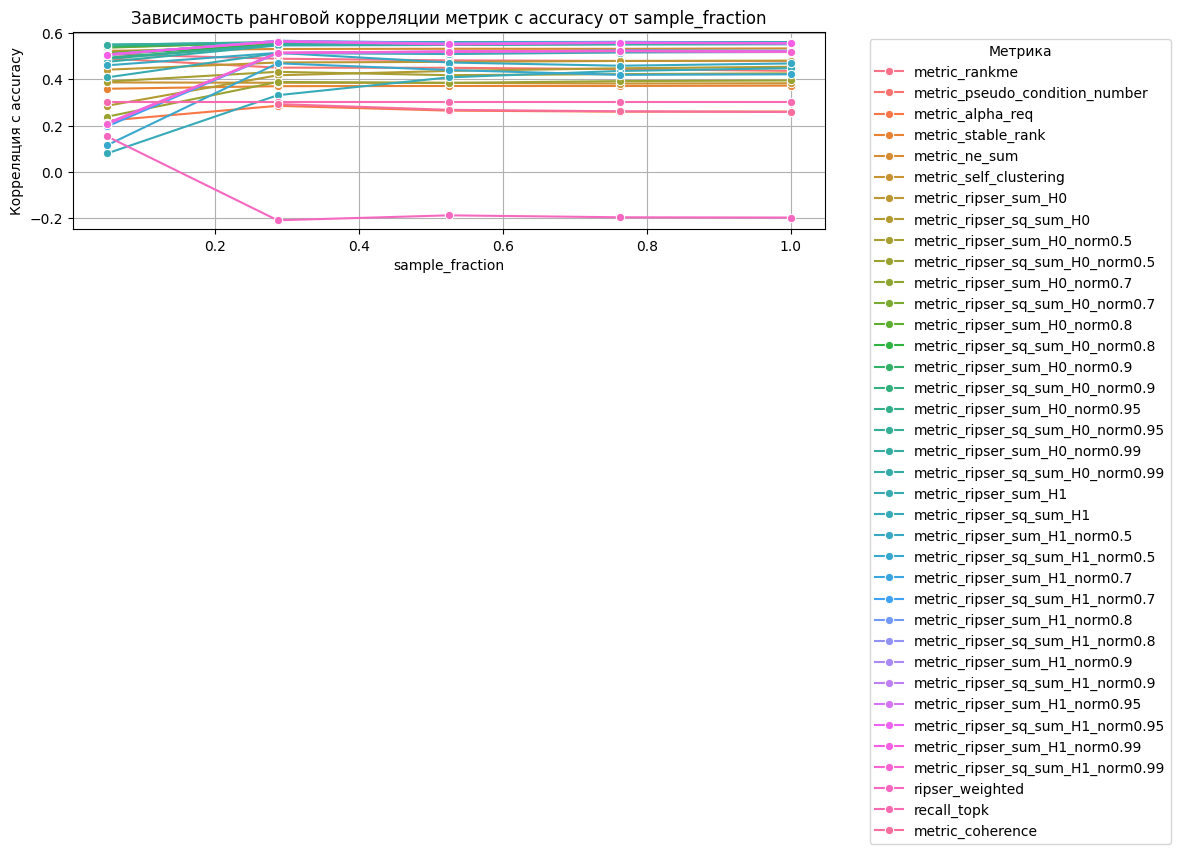

split_count


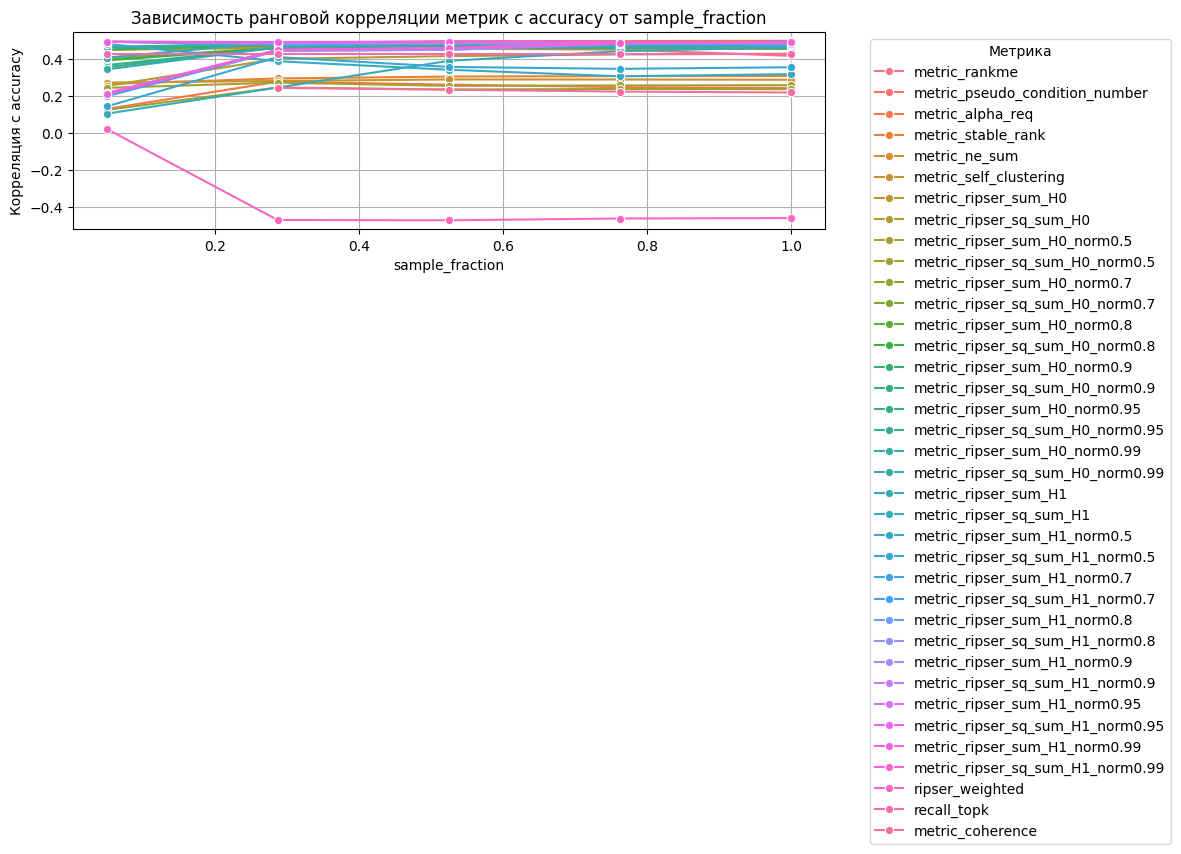

cnt_min


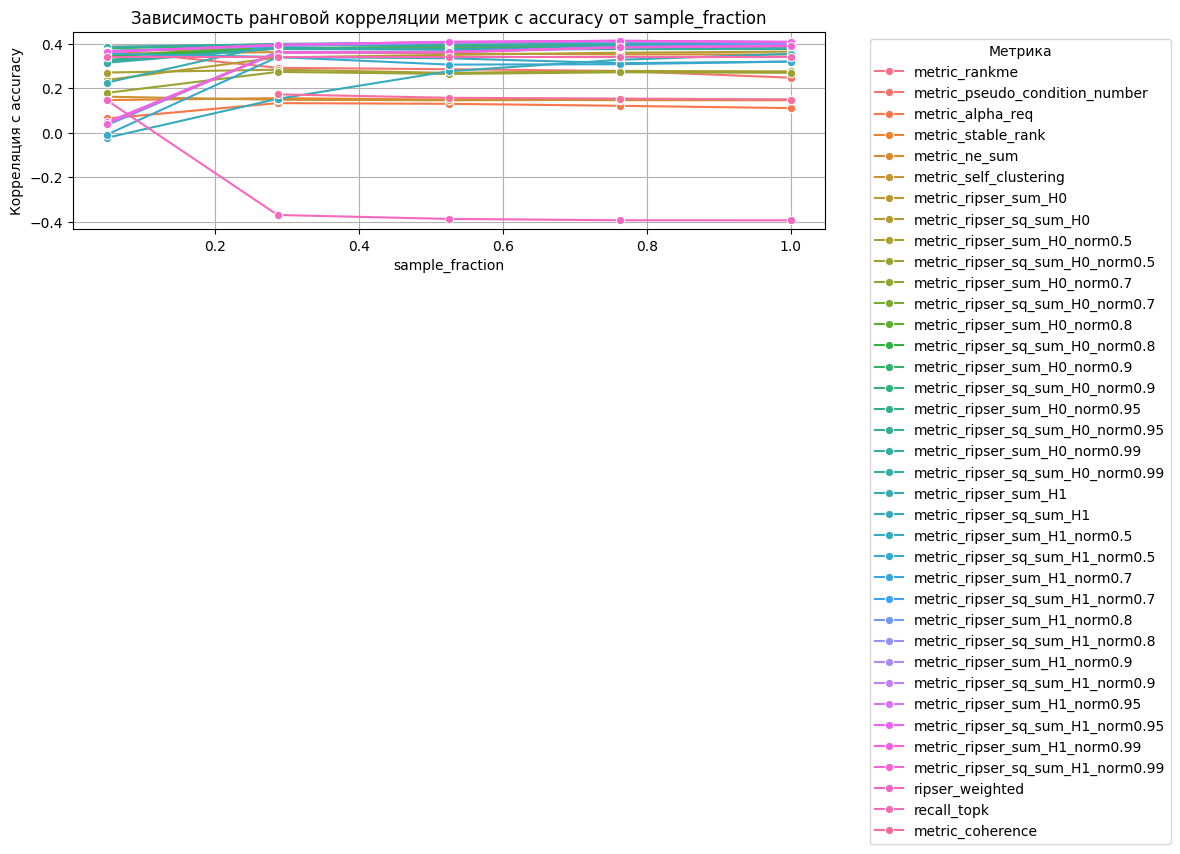

cnt_max


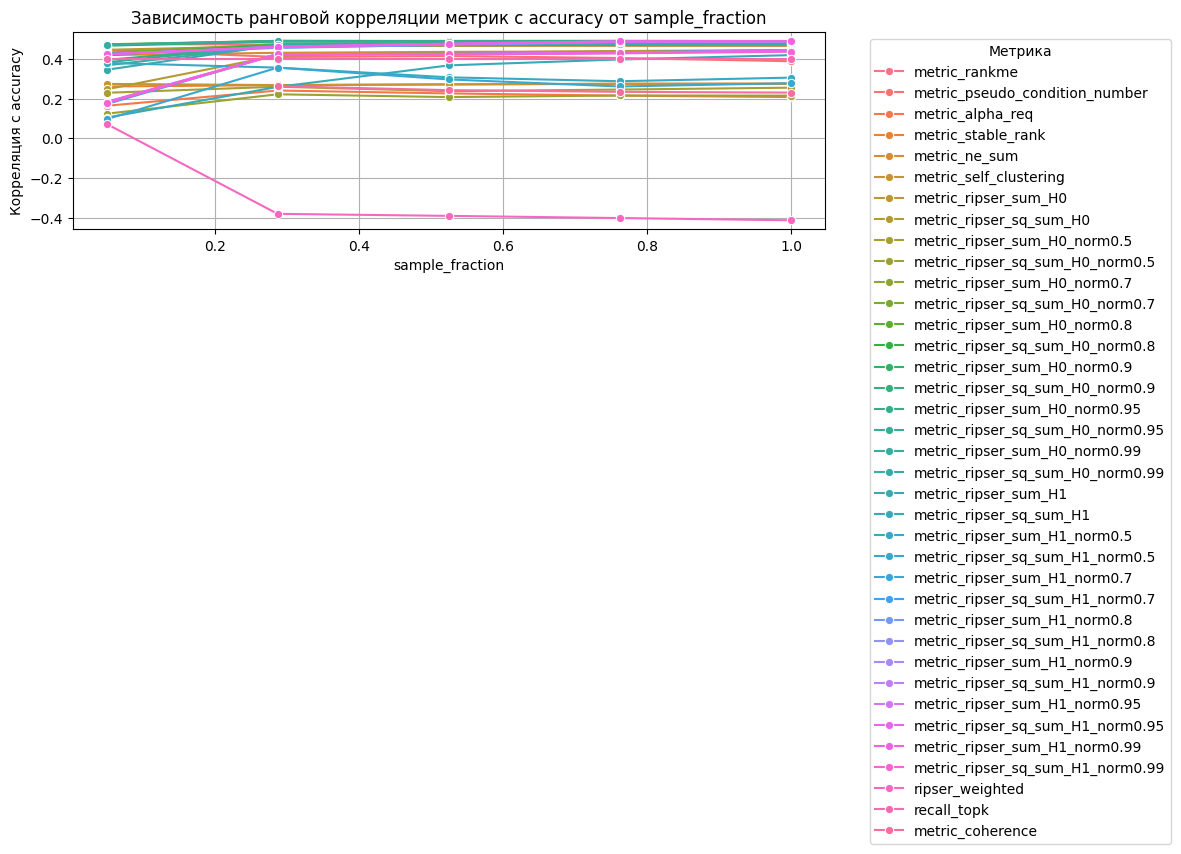

embedding_dim


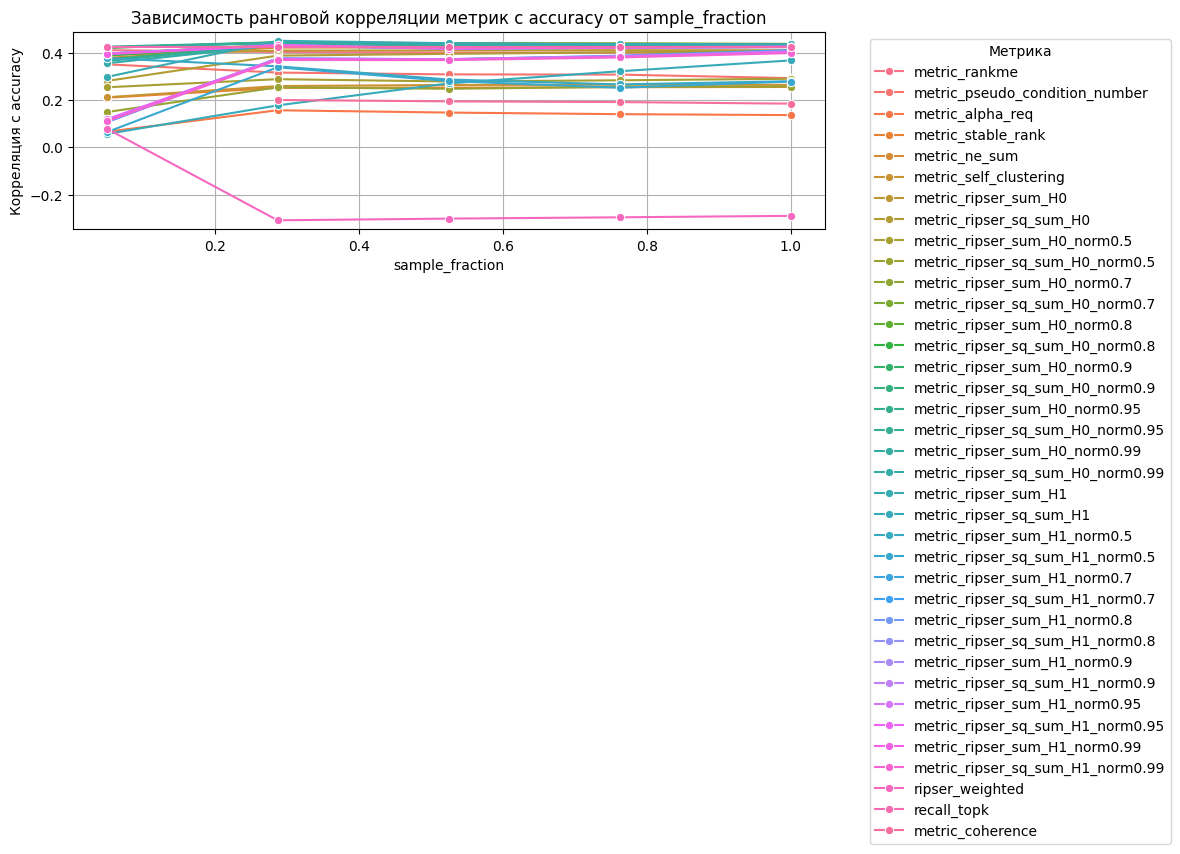

category_embedding_dim


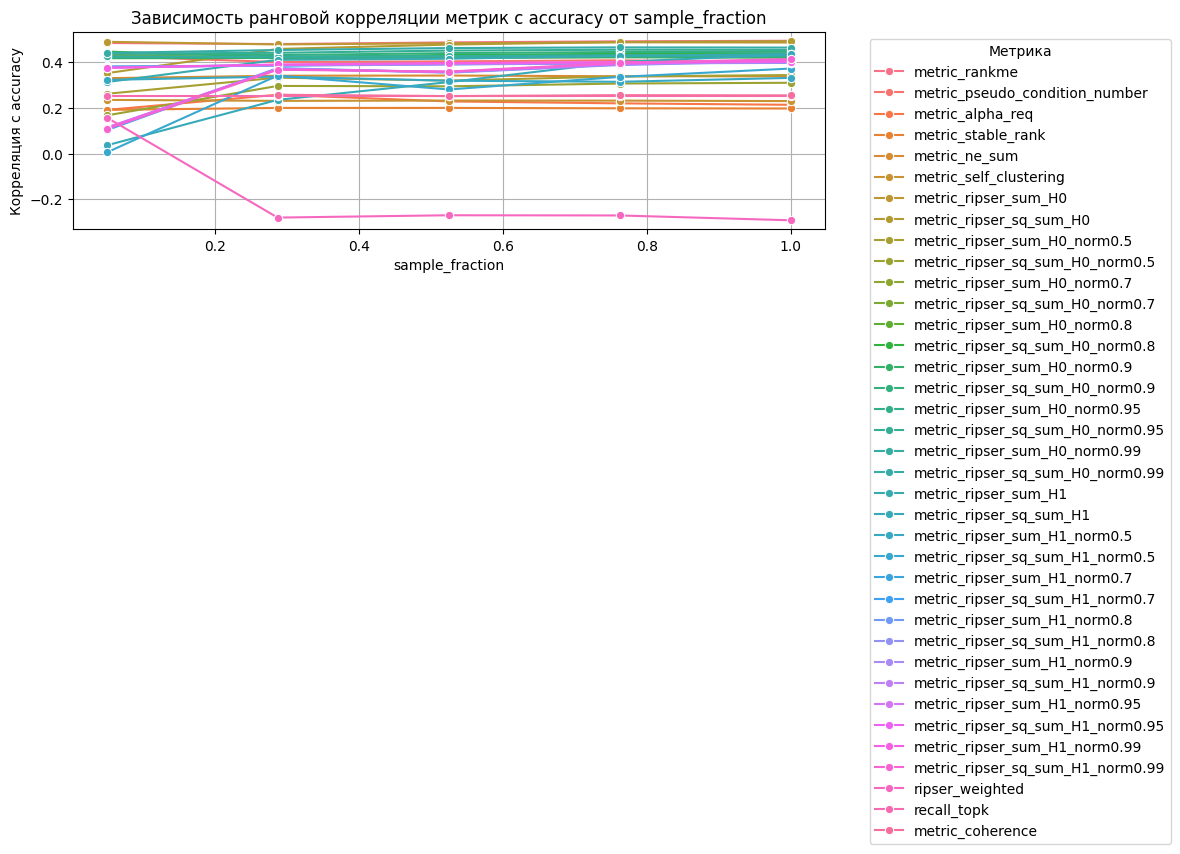

hidden_size


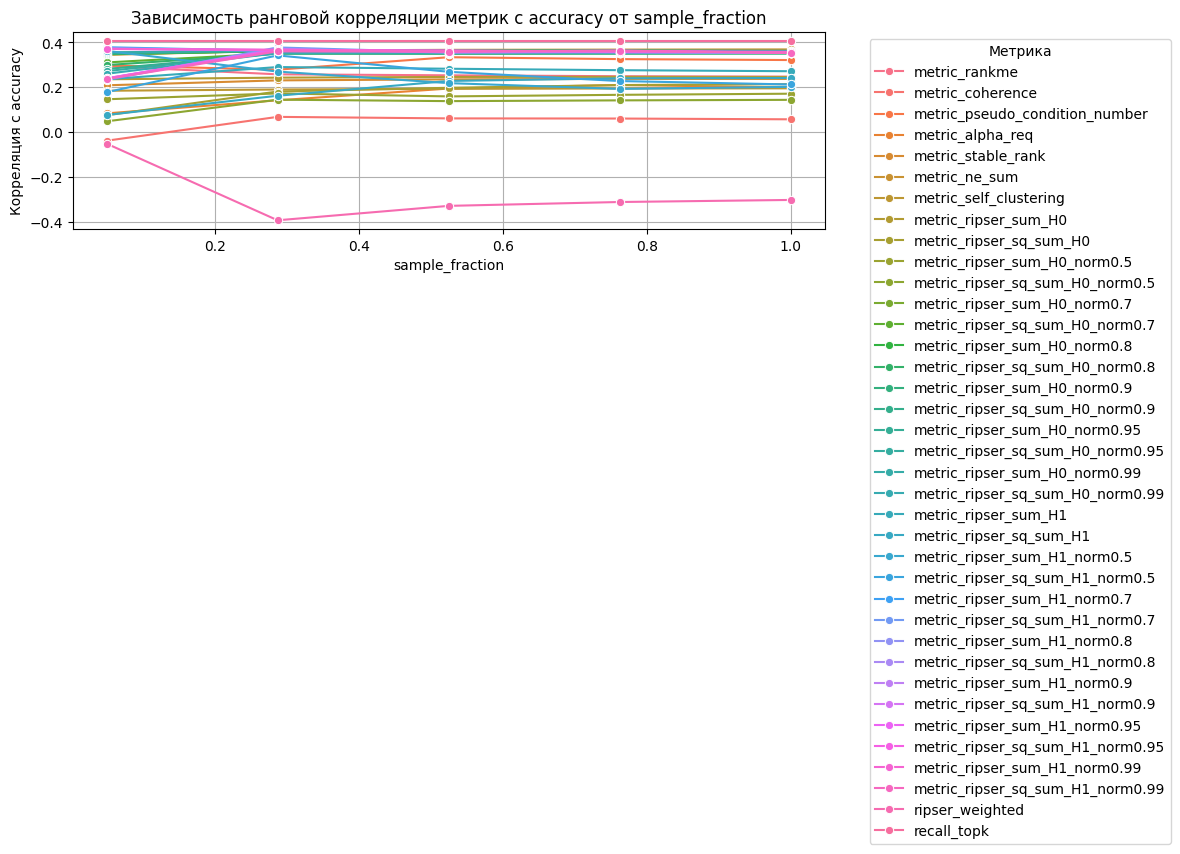

In [34]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [35]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0_norm0.95       0.444485
metric_ripser_sum_H0_norm0.99       0.443542
metric_ne_sum                       0.441011
metric_ripser_sum_H0_norm0.8        0.440263
metric_ripser_sum_H0_norm0.9        0.439567
metric_ripser_sum_H0_norm0.7        0.439524
metric_ripser_sum_H1_norm0.95       0.425733
metric_ripser_sum_H1_norm0.99       0.425637
metric_ripser_sum_H1_norm0.9        0.424754
metric_ripser_sum_H1_norm0.7        0.423589
metric_ripser_sum_H1_norm0.8        0.423086
metric_rankme                       0.420919
metric_ripser_sq_sum_H0_norm0.7     0.412682
metric_pseudo_condition_number      0.409556
metric_ripser_sq_sum_H0_norm0.8     0.404455
metric_ripser_sum_H1                0.397185
metric_ripser_sum_H0                0.394584
metric_ripser_sq_sum_H0_norm0.9     0.390542
metric_ripser_sq_sum_H0_norm0.95    0.385768
metric_ripser_sq_sum_H0_norm0.99    0.374504
recall_topk                         0.362653
metric_ripser_sum_H1_norm0.5        0

# Score of best hyperparams by metric

In [36]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    
                    pick = check_data['roc_auc'].values[
                        np.argmax(sign * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

/tmp/ipykernel_1337980/1720613291.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1337980/1720613291.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1337980/1720613291.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


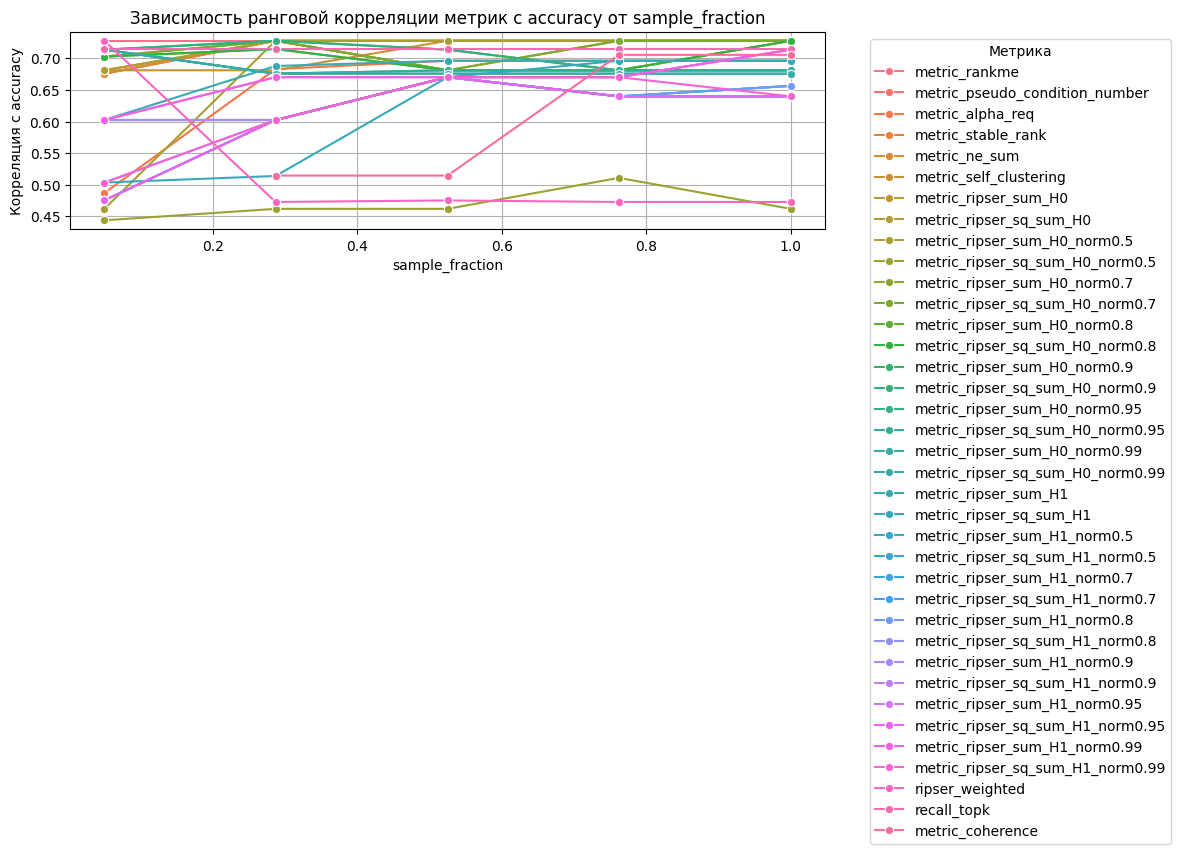

learning_rate


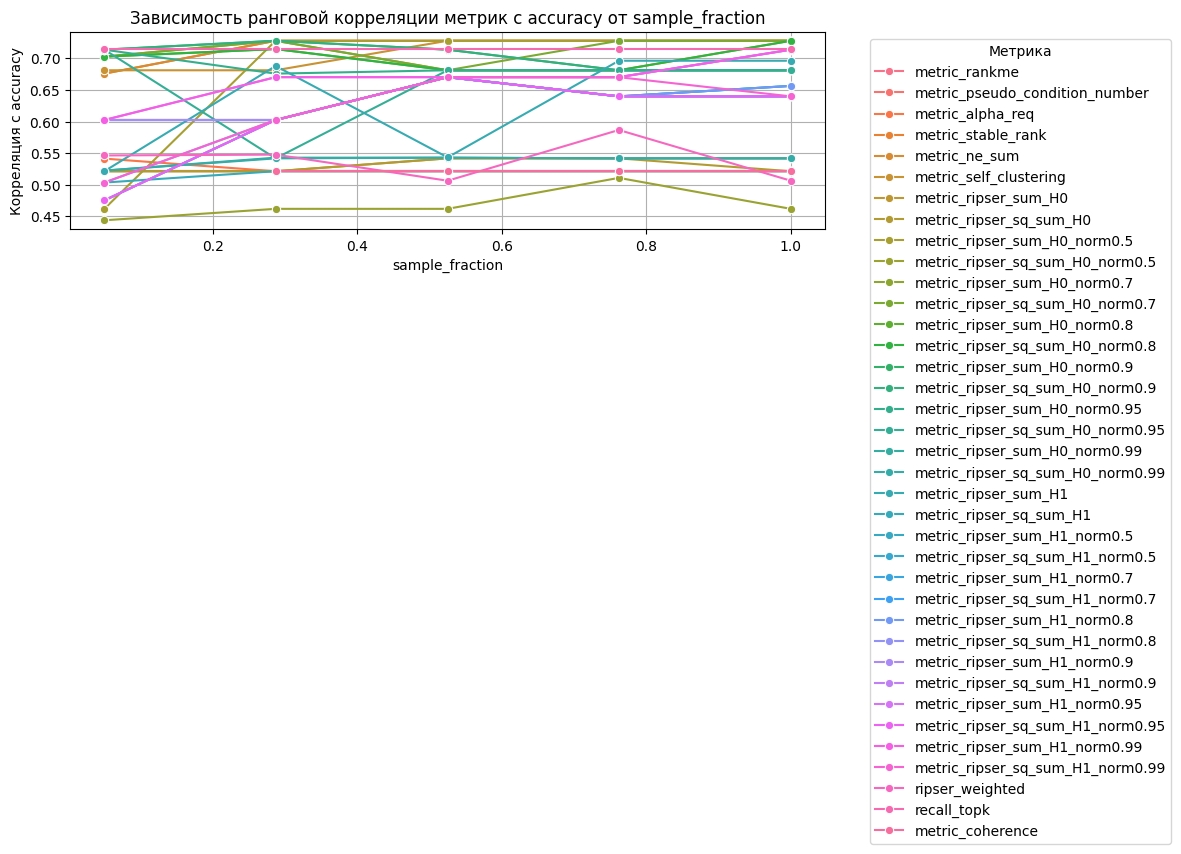

split_count


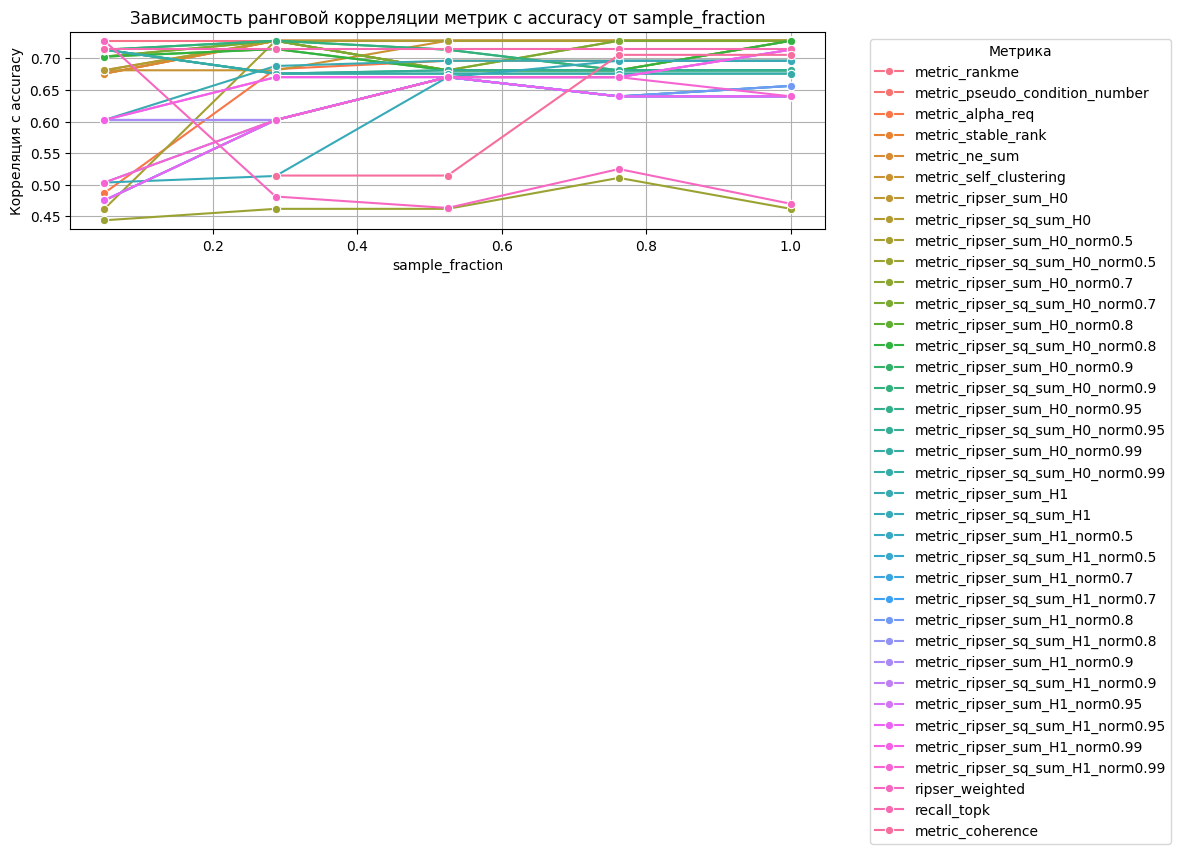

cnt_min


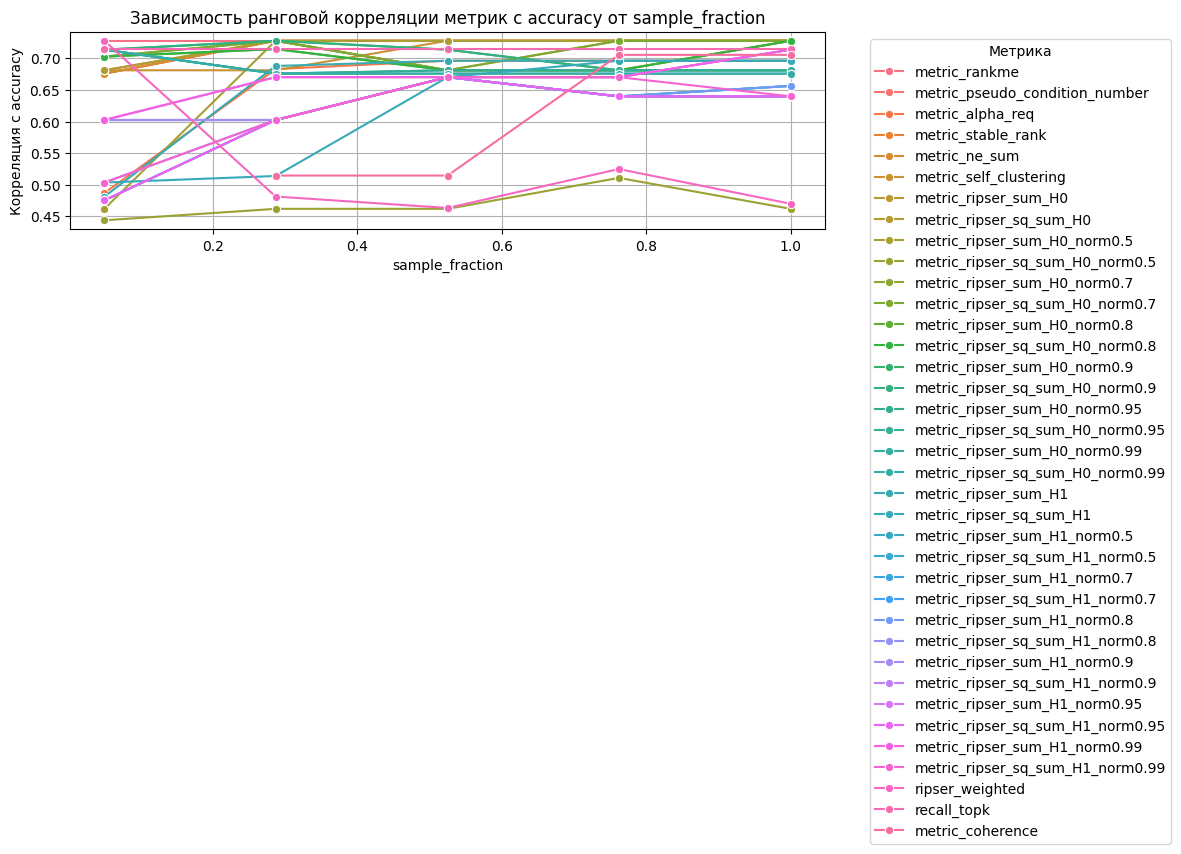

cnt_max


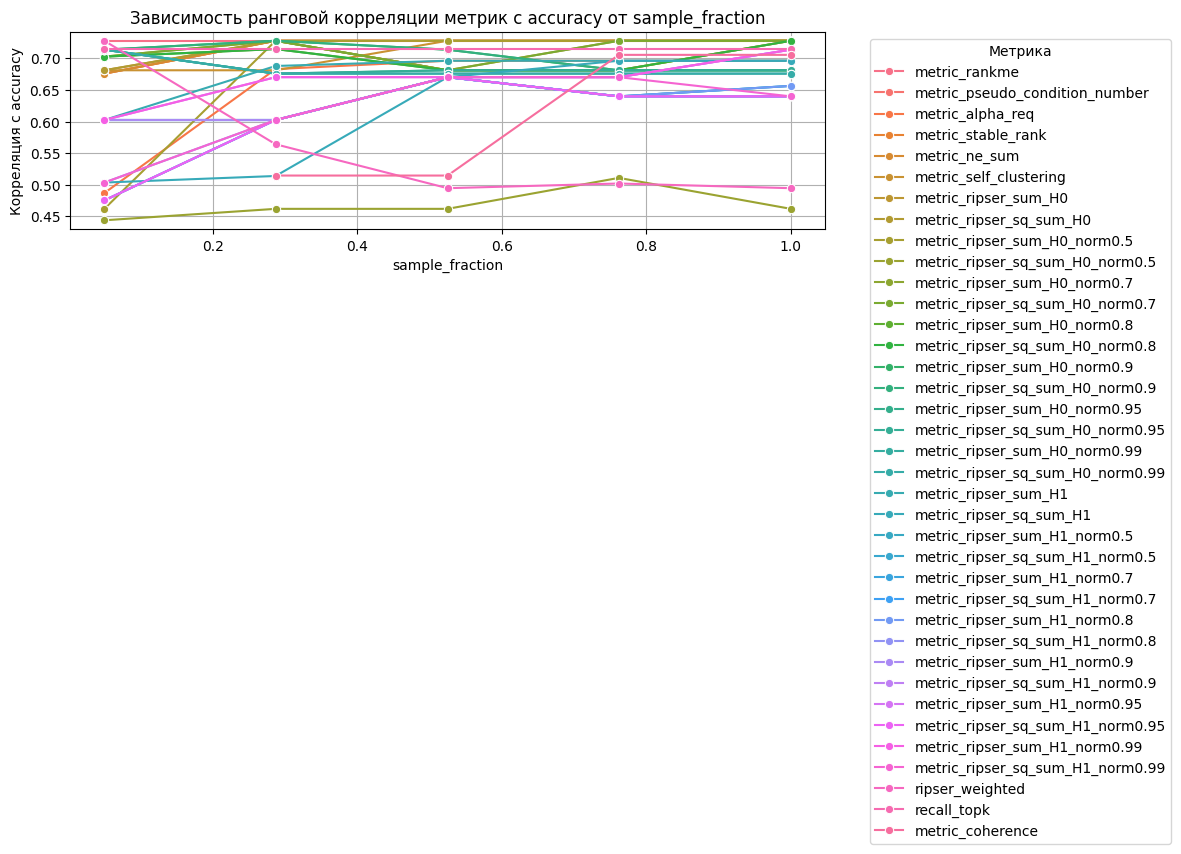

embedding_dim


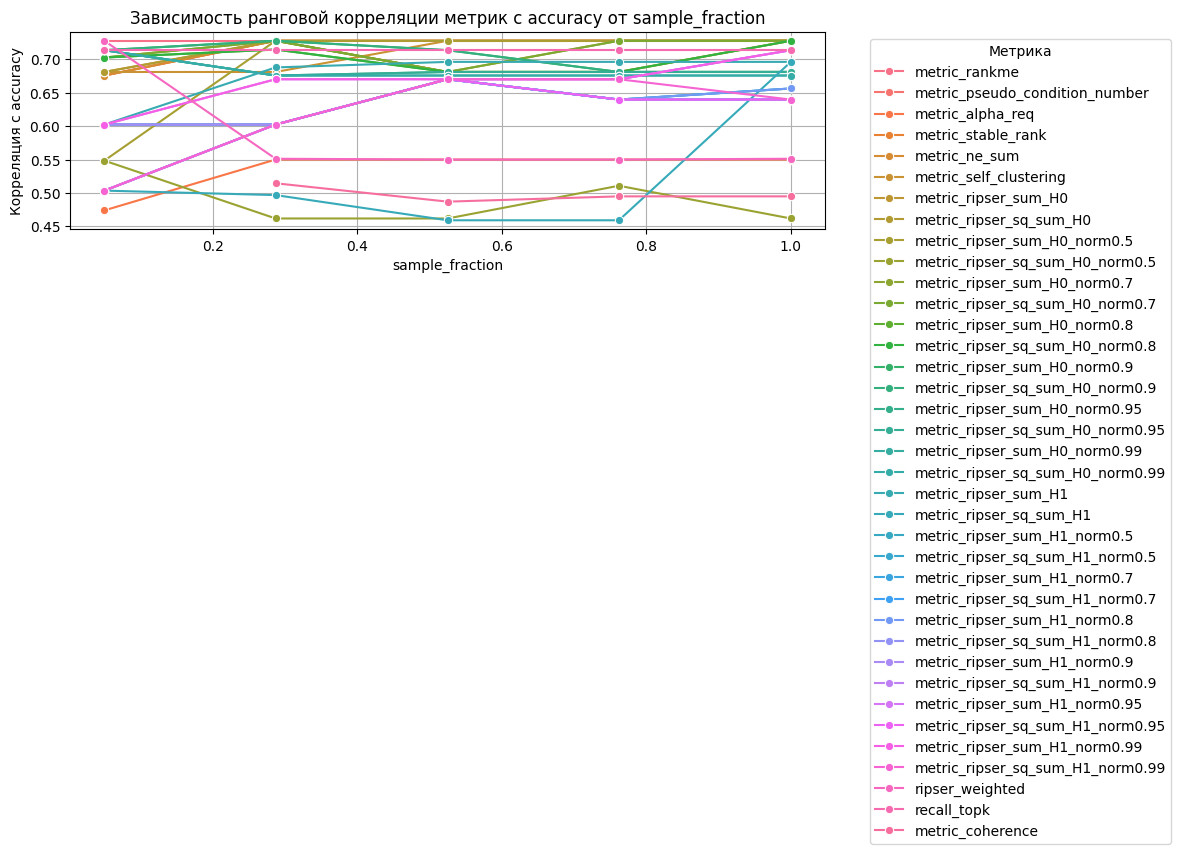

category_embedding_dim


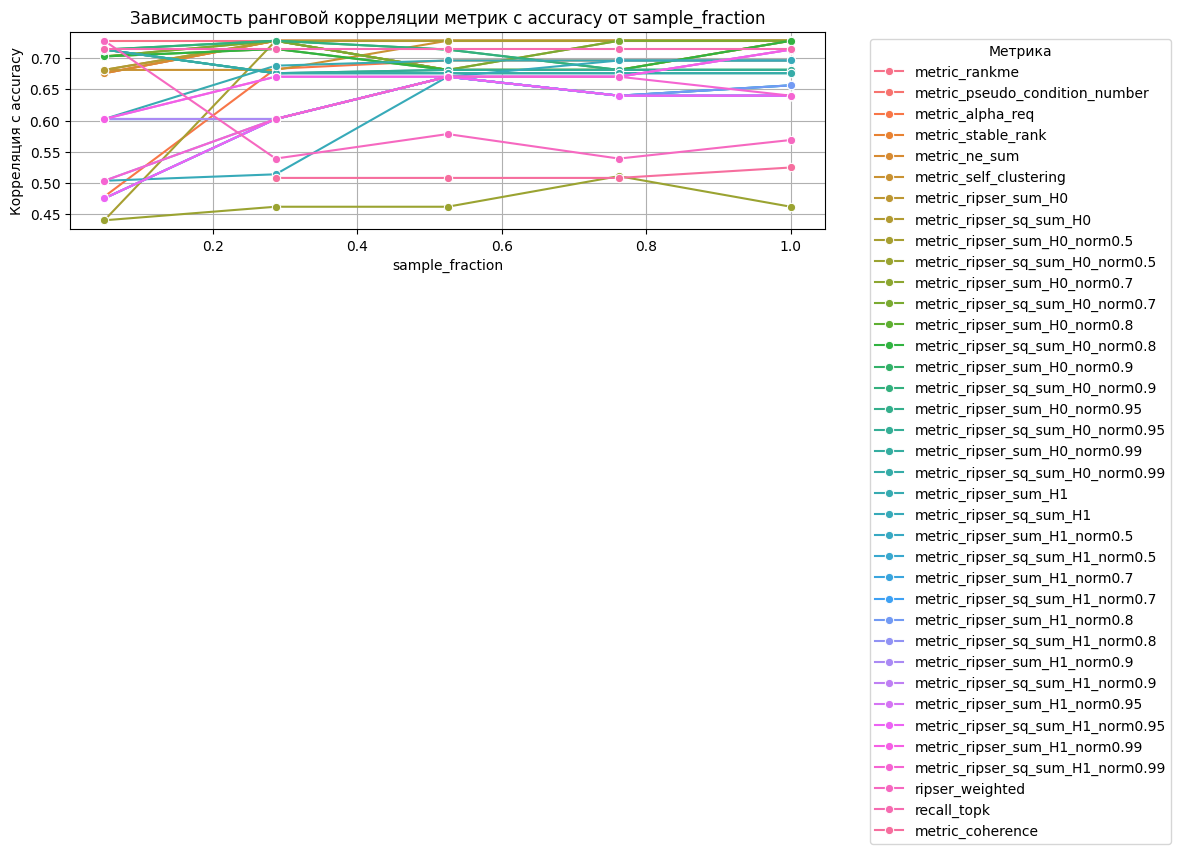

hidden_size


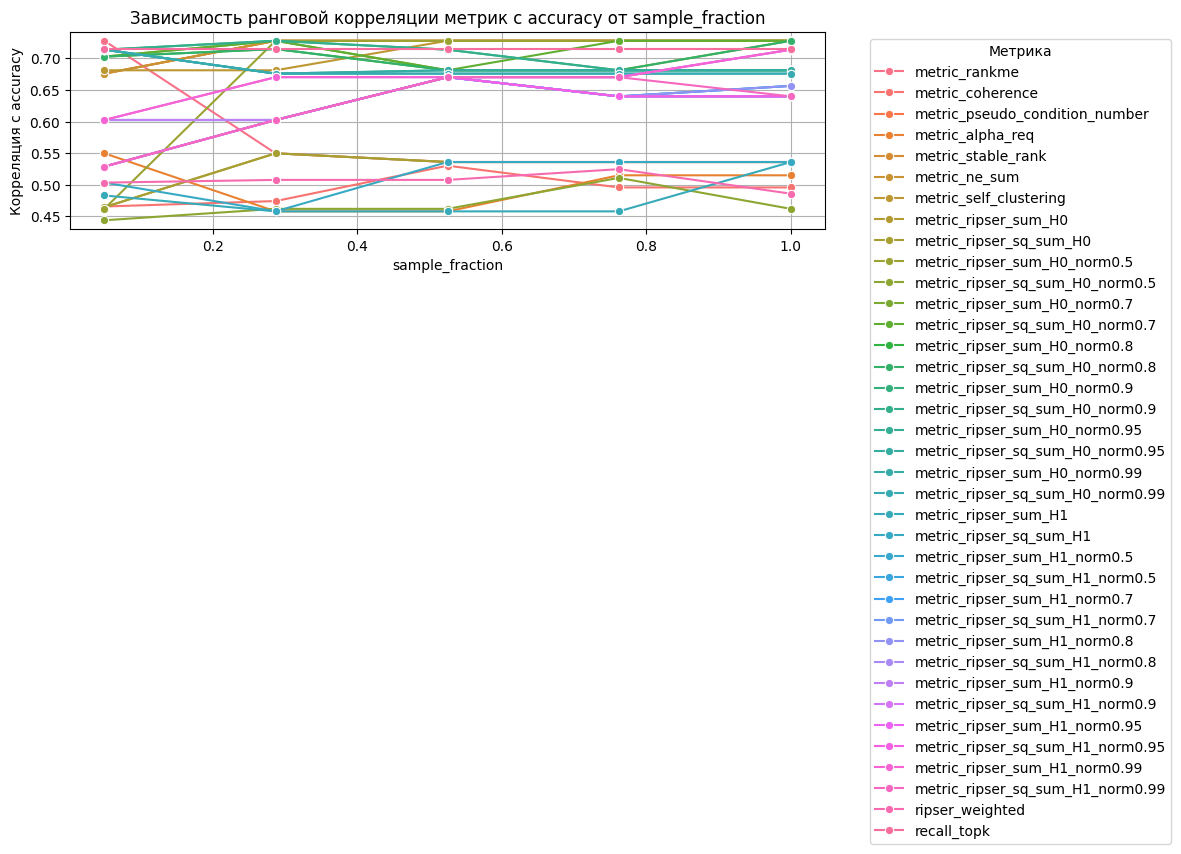

In [37]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [38]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_rankme                       0.72780
metric_ripser_sum_H0_norm0.9        0.72075
metric_ripser_sq_sum_H0_norm0.9     0.72075
metric_ripser_sq_sum_H0_norm0.7     0.71525
metric_ripser_sum_H0_norm0.7        0.71525
recall_topk                         0.71470
metric_ripser_sum_H0_norm0.8        0.70870
metric_ripser_sq_sum_H0_norm0.8     0.70870
metric_ripser_sq_sum_H0             0.70445
metric_ripser_sum_H0                0.70445
metric_stable_rank                  0.70180
metric_ne_sum                       0.70180
metric_pseudo_condition_number      0.70180
metric_ripser_sq_sum_H0_norm0.95    0.69475
metric_ripser_sq_sum_H0_norm0.99    0.69475
metric_ripser_sum_H0_norm0.95       0.69475
metric_ripser_sum_H0_norm0.99       0.69475
metric_self_clustering              0.68110
metric_ripser_sum_H1                0.64515
metric_ripser_sum_H1_norm0.95       0.63630
metric_ripser_sum_H1_norm0.99       0.63630
metric_ripser_sum_H1_norm0.8        0.60240
metric_ripser_

In [39]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ne_sum                       0.7278
metric_rankme                       0.7278
metric_pseudo_condition_number      0.7278
metric_ripser_sq_sum_H0_norm0.7     0.7278
metric_ripser_sq_sum_H0             0.7278
metric_ripser_sum_H0_norm0.5        0.7278
metric_self_clustering              0.7278
metric_ripser_sq_sum_H0_norm0.8     0.7278
metric_ripser_sum_H0                0.7278
metric_stable_rank                  0.7278
metric_ripser_sum_H0_norm0.7        0.7278
recall_topk                         0.7147
metric_ripser_sum_H1_norm0.99       0.7137
metric_ripser_sum_H1_norm0.95       0.7137
metric_ripser_sum_H1_norm0.9        0.7137
metric_coherence                    0.7055
metric_alpha_req                    0.6962
metric_ripser_sum_H1                0.6962
metric_ripser_sq_sum_H1             0.6962
metric_ripser_sq_sum_H0_norm0.95    0.6811
metric_ripser_sq_sum_H0_norm0.9     0.6811
metric_ripser_sum_H0_norm0.8        0.6811
metric_ripser_sum_H0_norm0.9        

In [40]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_rankme                       0.72780
metric_pseudo_condition_number      0.71740
metric_ne_sum                       0.71740
metric_stable_rank                  0.71740
recall_topk                         0.71470
metric_ripser_sq_sum_H0_norm0.7     0.71344
metric_ripser_sq_sum_H0             0.70912
metric_self_clustering              0.70912
metric_ripser_sum_H0_norm0.7        0.70410
metric_ripser_sq_sum_H0_norm0.9     0.70348
metric_ripser_sum_H0_norm0.9        0.70348
metric_ripser_sq_sum_H0_norm0.8     0.70148
metric_ripser_sum_H0                0.69978
metric_ripser_sum_H0_norm0.8        0.69214
metric_ripser_sum_H0_norm0.95       0.68656
metric_ripser_sq_sum_H0_norm0.95    0.68656
metric_ripser_sum_H0_norm0.99       0.68338
metric_ripser_sq_sum_H0_norm0.99    0.68338
metric_ripser_sum_H1                0.67578
metric_ripser_sum_H0_norm0.5        0.67460
metric_ripser_sum_H1_norm0.99       0.66534
metric_ripser_sum_H1_norm0.95       0.66534
metric_ripser_

In [41]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_rankme                       0.72780
metric_pseudo_condition_number      0.71740
metric_ne_sum                       0.71740
metric_stable_rank                  0.71740
recall_topk                         0.71470
metric_ripser_sq_sum_H0_norm0.7     0.71344
metric_ripser_sq_sum_H0             0.70912
metric_self_clustering              0.70912
metric_ripser_sum_H0_norm0.7        0.70410
metric_ripser_sq_sum_H0_norm0.9     0.70348
metric_ripser_sum_H0_norm0.9        0.70348
metric_ripser_sq_sum_H0_norm0.8     0.70148
metric_ripser_sum_H0                0.69978
metric_ripser_sum_H0_norm0.8        0.69214
metric_ripser_sum_H0_norm0.95       0.68656
metric_ripser_sq_sum_H0_norm0.95    0.68656
metric_ripser_sum_H0_norm0.99       0.68338
metric_ripser_sq_sum_H0_norm0.99    0.68338
metric_ripser_sum_H1                0.67578
metric_ripser_sum_H0_norm0.5        0.67460
metric_ripser_sum_H1_norm0.99       0.66534
metric_ripser_sum_H1_norm0.95       0.66534
metric_ripser_

# Standard deviation of score of best param selection

In [42]:
std_corr = {}
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    std_corr[param] = corr_df.groupby("metric")["auc"].std().sort_values()

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


batch_size


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


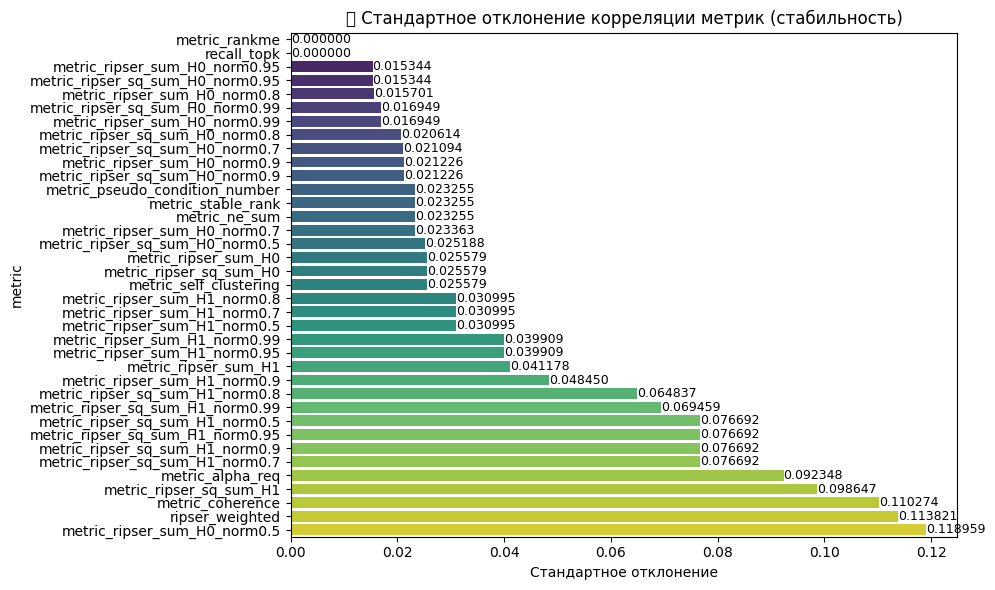

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


learning_rate


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


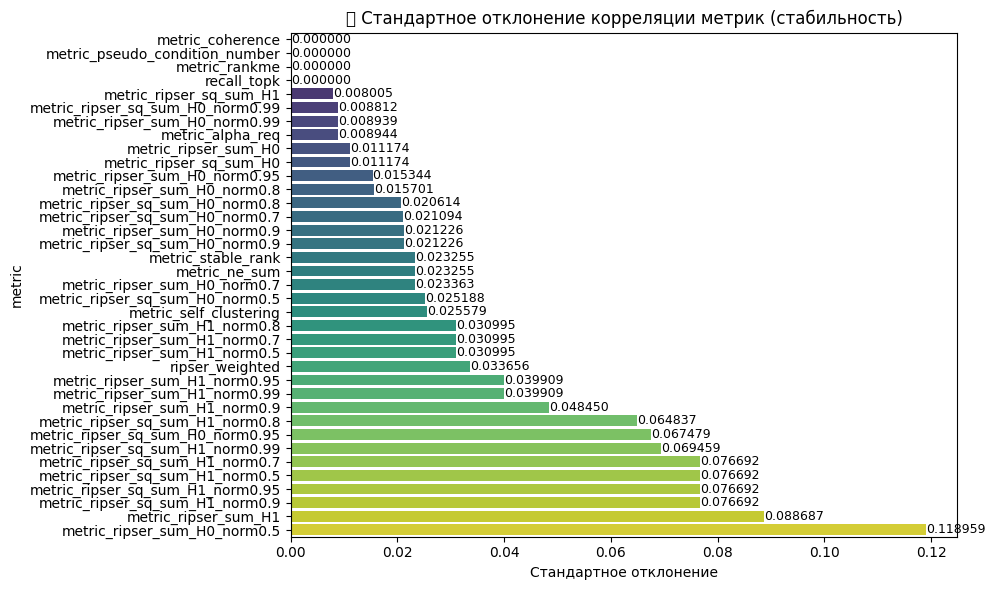

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


split_count


/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


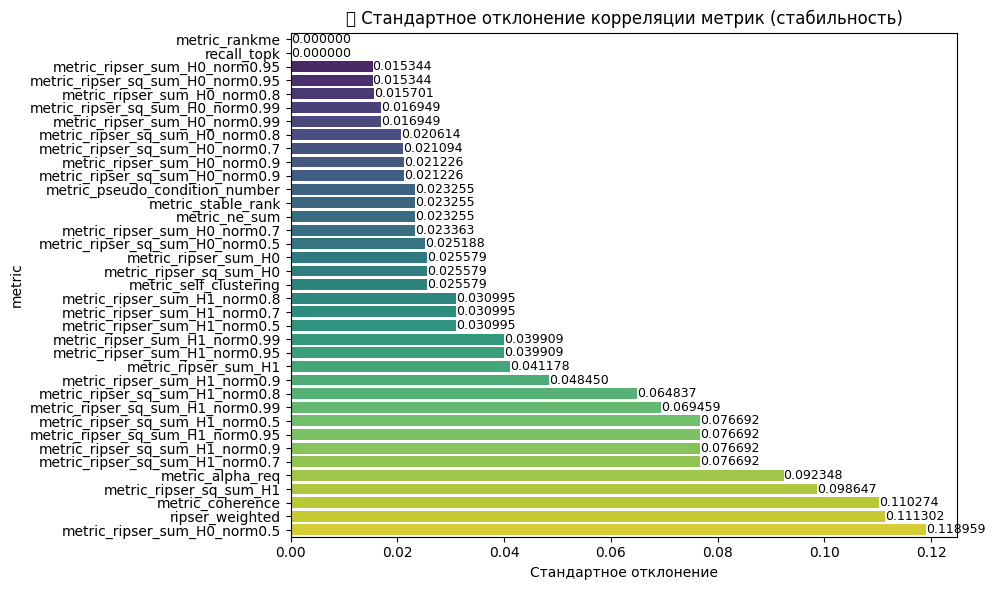

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


cnt_min


/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


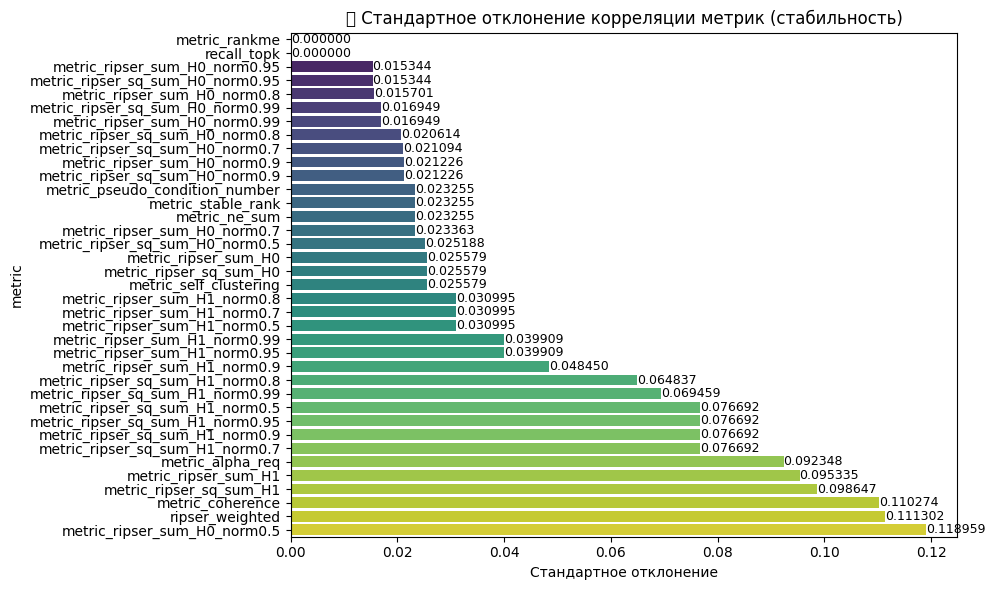

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_max


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


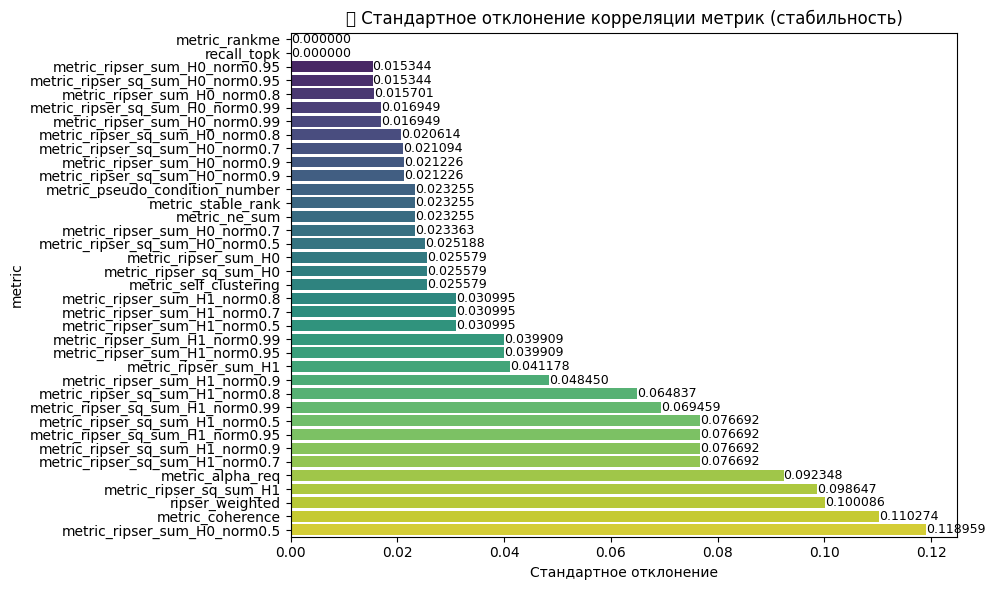

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


embedding_dim


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


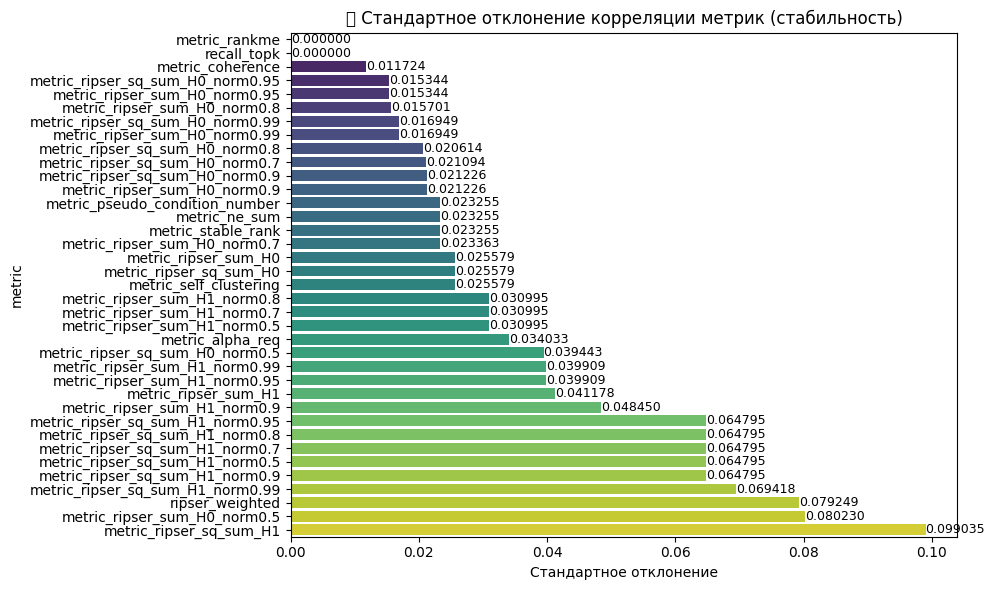

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


category_embedding_dim


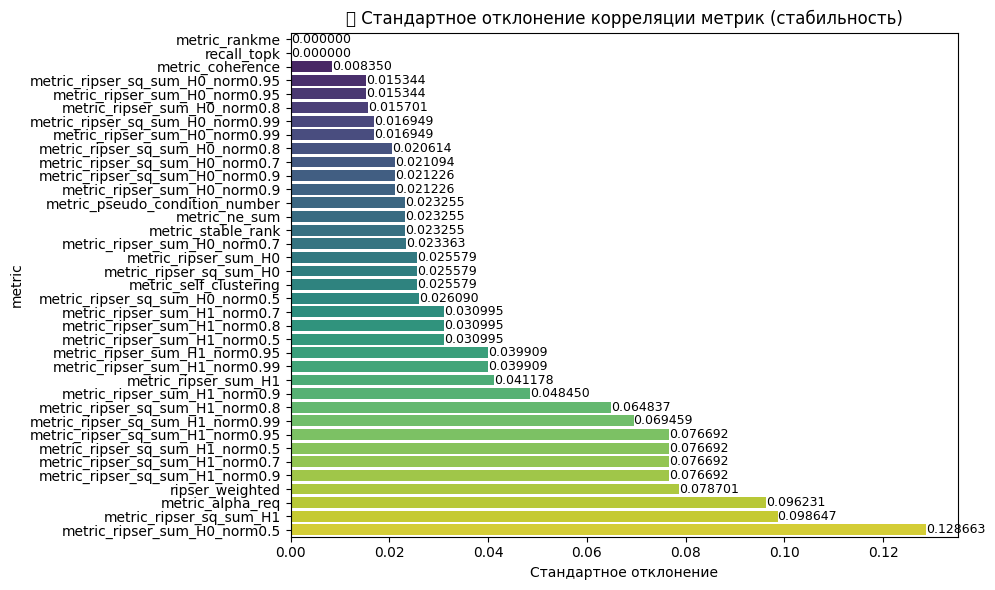

/tmp/ipykernel_1337980/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


hidden_size


/tmp/ipykernel_1337980/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


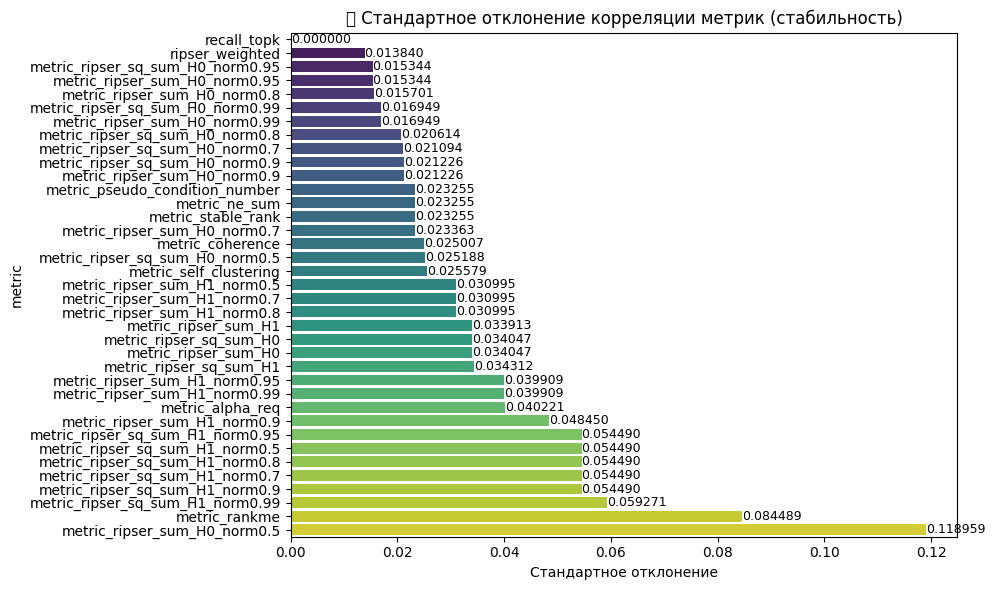

In [43]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()